## Pre

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import xesmf as xe
import intake
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from scipy.stats import pearsonr
import gsw
import sys
import os
import gc
import cftime
import cmocean.cm as cm
sys.path.append('/g/data/jk72/zc0441')
from zpackage import wmt
# from zpackage.zclef_v2 import *
from zpackage.ztake import *


### GhatGPT API

### intake cat

In [5]:
cat = intake.cat.access_nri
# cmip6 = cat['esgf'].cmip6
# cat["cmip6_fs38"]

# cat["cmip6_fs38"]


In [6]:
# cat["cmip6_oi10"]

In [7]:
cmip6 = intake.open_esm_datastore("/g/data/dk92/catalog/v2/esm/cmip6-oi10/catalog.json")

In [8]:
# df_thetao = variable_df(['thetao'])

# cmip6 = intake.open_esm_datastore("/g/data/dk92/catalog/v2/esm/cmip6-oi10/catalog.json")
# cat = intake.cat.nci
# cmip6 = cat['esgf'].cmip6

constraints = dict(
    experiment_id="historical",
    variable_id="thetao",
    member_id=["r1i1p1f1"],
    table_id="Omon"
)

# Build your Ztake
zt_thetao_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           # prefer_grids=("gn", "gr","gr1")
           prefer_grids=("gr", "gn","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [9]:
# zt_thetao_hist._best_df

In [10]:
# zt_thetao_hist._model_list

In [11]:
model_list_1 = [
 'ACCESS-CM2',
 'CAS-ESM2-0',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 'CIESM',
 'CMCC-CM2-SR5',
 'CMCC-ESM2',
 'CNRM-CM6-1',
 'CNRM-ESM2-1',
 'FGOALS-f3-L',
 'FGOALS-g3',
 'IPSL-CM6A-LR',
 'IPSL-CM6A-LR-INCA',
 'MPI-ESM-1-2-HAM',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 # 'MRI-ESM2-0',
 'NorESM2-LM',
 'NorESM2-MM',
 'UKESM1-0-LL'
]
base_data_dir = '/g/data/jk72/zc0441/Subject_2/data/'
time_range = slice('1979','2014')

In [12]:
def esgf_search(server="https://esgf-node.llnl.gov/esg-search/search",
                files_type="OPENDAP", local_node=True, project="CMIP6",
                verbose=False, format="application%2Fsolr%2Bjson",
                use_csrf=False, **search):
    client = requests.session()
    payload = search
    payload["project"] = project
    payload["type"]= "File"
    if local_node:
        payload["distrib"] = "false"
    if use_csrf:
        client.get(server)
        if 'csrftoken' in client.cookies:
            # Django 1.6 and up
            csrftoken = client.cookies['csrftoken']
        else:
            # older versions
            csrftoken = client.cookies['csrf']
        payload["csrfmiddlewaretoken"] = csrftoken

    payload["format"] = format

    offset = 0
    numFound = 10000
    all_files = []
    files_type = files_type.upper()
    while offset < numFound:
        payload["offset"] = offset
        url_keys = []
        for k in payload:
            url_keys += ["{}={}".format(k, payload[k])]

        url = "{}/?{}".format(server, "&".join(url_keys))
        print(url)
        r = client.get(url)
        r.raise_for_status()
        resp = r.json()["response"]
        numFound = int(resp["numFound"])
        resp = resp["docs"]
        offset += len(resp)
        for d in resp:
            if verbose:
                for k in d:
                    print("{}: {}".format(k,d[k]))
            url = d["url"]
            for f in d["url"]:
                sp = f.split("|")
                if sp[-1] == files_type:
                    all_files.append(sp[0].split(".html")[0])
    return sorted(all_files)

In [13]:
def plot_xy_grouped(
    x_da, y_da, model_series, models=None, colors=None,
    marker_cycle=('o','s','^','v','D','P','X','*','h','+','x'),
    line_color='firebrick', xlabel=None, ylabel=None,
    ax=None, annotate_stats=True, draw_fit=True,
    legend_all_models=True
):
    if colors is None:
        colors = plt.cm.tab20.colors

    series_names = list(model_series.keys())
    series_colors = {s: colors[i % len(colors)] for i, s in enumerate(series_names)}

    if models is None:
        models = [m for s in series_names for m in model_series[s]]

    x_all = x_da.sel(model=models).to_numpy()
    y_all = y_da.sel(model=models).to_numpy()
    mask = np.isfinite(x_all) & np.isfinite(y_all)
    x_all, y_all = x_all[mask], y_all[mask]
    models_masked = [m for k, m in enumerate(models) if mask[k]]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8,6))

    if len(x_all) >= 2 and draw_fit:
        m_fit, b_fit = np.polyfit(x_all, y_all, 1)
        xx = np.linspace(x_all.min(), x_all.max(), 200)
        yy = m_fit * xx + b_fit
        ax.plot(xx, yy, color=line_color, linestyle='--', linewidth=1.5)
        if annotate_stats:
            r, p = pearsonr(x_all, y_all)
            ax.text(0.03, 0.92, f'r = {r:.2f}\np = {p:.2g}',
                    transform=ax.transAxes, ha='left', va='top',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    legend_handles = []

    for i, s in enumerate(series_names):
        col = series_colors[s]
        series_models = [m for m in model_series[s] if m in models_masked]
        for j, m in enumerate(series_models):
            mk = marker_cycle[j % len(marker_cycle)]
            xi = float(x_da.sel(model=m))
            yi = float(y_da.sel(model=m))
            sc = ax.scatter(xi, yi, s=60, facecolor=col, edgecolor='k',
                            marker=mk, linewidth=0.8, zorder=3)
            if legend_all_models:
                legend_handles.append(
                    plt.Line2D([0],[0], marker=mk, color='w',
                               markerfacecolor=col, markeredgecolor='k',
                               markersize=8, label=m)
                )

    ax.set_xlabel(xlabel or (x_da.name if x_da.name else 'X'), fontsize=12)
    ax.set_ylabel(ylabel or (y_da.name if y_da.name else 'Y'), fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)

    if legend_all_models and legend_handles:
        ax.legend(handles=legend_handles,
                  # title='Models',
                  # fontsize=7, frameon=False, loc='lower right', ncol=2)
                  fontsize=7, frameon=False, loc='upper right', ncol=2)
        

    return ax


In [14]:
def get_lat_lon_lev_coords(dataset: xr.Dataset) -> tuple:
    """
    Determine the latitude and longitude coordinate names in an xarray dataset.

    Args:
        dataset (xr.Dataset): The dataset to check.

    Returns:
        tuple: A tuple containing the names of the latitude and longitude coordinates (lat_coord, lon_coord).
    """
    lat_coord = (
        'nav_lat' if 'nav_lat' in dataset.coords else
        'latitude' if 'latitude' in dataset.coords else
        'lat' if 'lat' in dataset.coords else None
    )
    
    lon_coord = (
        'nav_lon' if 'nav_lon' in dataset.coords else
        'longitude' if 'longitude' in dataset.coords else
        'lon' if 'lon' in dataset.coords else None
    )
    
    lev_coord = (
        'lev' if 'lev' in dataset.coords else
        'olevel' if 'olevel' in dataset.coords else
        'nlev' if 'nlev' in dataset.coords else None
    )
    if not lat_coord or not lon_coord:
        raise ValueError("Latitude and/or longitude coordinates not found in the dataset.")

    return lat_coord, lon_coord, lev_coord

In [15]:
def get_j_i_dims(dataset: xr.Dataset) -> tuple:
    """
    Determine the latitude and longitude coordinate names in an xarray dataset.

    Args:
        dataset (xr.Dataset): The dataset to check.

    Returns:
        tuple: A tuple containing the names of the latitude and longitude coordinates (lat_coord, lon_coord).
    """
    i_dim = (
        'i' if 'i' in dataset.dims else
        'x' if 'x' in dataset.dims else
        'nlon' if 'nlon' in dataset.coords else None
    )
    
    j_dim = (
        'j' if 'j' in dataset.dims else
        'y' if 'y' in dataset.dims else
        'nlat' if 'nlat' in dataset.dims else None
    )
    
    if not j_dim or not i_dim:
        raise ValueError("Latitude and/or longitude coordinates not found in the dataset.")

    return j_dim, i_dim

In [16]:
def get_lat_profile(model):
    # thetao = load_data(model, time_range.start, time_range.stop, df_thetao, 'thetao')
    thetao = zt_thetao_hist.open_model('NorESM2-LM')["thetao"].sel(time = slice("1979", "2014"))
    

    thetao_lat = thetao.latitude.mean(dim = 'i').compute()  
    thetao_lat = thetao_lat.where(thetao_lat <-45, drop = True)
    return thetao_lat

## For loop to store the thetao 200 m

In [14]:
model_list_1#[9]

['ACCESS-CM2',
 'CAS-ESM2-0',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 'CIESM',
 'CMCC-CM2-SR5',
 'CMCC-ESM2',
 'CNRM-CM6-1',
 'CNRM-ESM2-1',
 'FGOALS-f3-L',
 'FGOALS-g3',
 'IPSL-CM6A-LR',
 'IPSL-CM6A-LR-INCA',
 'MPI-ESM-1-2-HAM',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'NorESM2-LM',
 'NorESM2-MM',
 'UKESM1-0-LL']

In [30]:
model =  'CIESM'
model =  'FGOALS-g3'
model =  'MPI-ESM-1-2-HAM'

thetao = load_data(model, time_range.start, time_range.stop, df_thetao, 'thetao')


In [31]:
# thetao_lat = thetao.latitude[:,-2].compute()



In [12]:
# load_data('CNRM-CM6-1', time_range.start, time_range.stop, df_thetao, 'thetao') #.mean(dim = 'nlon')
# thetao

In [16]:
# thetao = load_data(model, time_range.start, time_range.stop, df_thetao, 'thetao').load()
# j_dim, i_dim = get_j_i_dims(thetao)
# i_dim 


CNRM-CM6-1 done


In [6]:
model =  'IPSL-CM6A-LR'
thetao = load_data(model, time_range.start, time_range.stop, df_thetao, 'thetao')
lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(thetao)
j_dim, i_dim = get_j_i_dims(thetao)
lev_bound = 200


In [ ]:
gg = thetao.chunk({'time': 10})  # You can add j_dim/lev_coord here too
gg_1 = gg.where(gg[lat_coord] < -45).where(thetao[lev_coord] < lev_bound).compute()

In [7]:
for model in model_list_1[6:7]:
    thetao = load_data(model, time_range.start, time_range.stop, df_thetao, 'thetao')
    
    lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(thetao)
    j_dim, i_dim = get_j_i_dims(thetao)

    lev_bound = 200
    if 'CESM' in model:
        lev_bound = 20000

    # Subset and chunk
    thetao_45S_200m = (
        thetao
        .chunk({'time': 10})  # You can add j_dim/lev_coord here too
        .where(thetao[lat_coord] < -45, drop=True)
        .where(thetao[lev_coord] < lev_bound, drop=True)
    )
    # # Subset and chunk
    # thetao_45S_200m = thetao.where(thetao[lat_coord] < -45, drop=True).where(thetao[lev_coord] < lev_bound, drop=True)
    

    # Mean and compute
    thetao_45S_200m_profile = thetao_45S_200m.mean(dim=['time', i_dim]).compute()

    # Assign 1D lat coordinate if needed
    if thetao_45S_200m[lat_coord].ndim == 2:
        thetao_45S_200m_profile[lat_coord] = thetao_45S_200m[lat_coord].isel({i_dim: 0})

    # Save
    thetao_45S_200m_profile.to_netcdf(
        f"{base_data_dir}/{model}/thetao_45S_200m_profile_mean_{time_range.start}_{time_range.stop}.nc"
    )
    # Clear variables
    del thetao, thetao_45S_200m, thetao_45S_200m_profile
    
    # Run garbage collection
    gc.collect()
    print(f'{model} done')



/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.04/lib/python3.9/site-packages/xarray/core/indexing.py:1228: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


CIESM done


# For loop for 500m

In [22]:
constraints = dict(
    experiment_id="historical",
    variable_id="thetao",
    member_id=["r1i1p1f1", "r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_thetao_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           # prefer_grids=("gn", "gr","gr1")
           prefer_grids=("gr", "gn","gr1")
          )

In [23]:
model_list_3[-3:-1]

['NorESM2-LM', 'NorESM2-MM']

In [24]:
for model in model_list_3[-3:-1]:#[8:9]:
    # thetao = load_data(model, time_range.start, time_range.stop, df_thetao, 'thetao')
    thetao = zt_thetao_hist.open_model(model)["thetao"].sel(time = slice("1979","2014"))
    
    lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(thetao)
    # if 'CESM' in model:
    #     j_dim, i_dim = "lat", "lon"
    # else:
    j_dim, i_dim = get_j_i_dims(thetao)
    if "CMCC" in model:
        j_dim = "i"
        i_dim = "j"
        
    lev_bound = 600
    if 'CESM' in model:
        lev_bound = 60000

    # Subset and chunk
    thetao_45S_200m = (
        thetao
        .chunk({'time': 10})  # You can add j_dim/lev_coord here too
        .where(thetao[lat_coord].compute() < -45, drop=True)
        .where(thetao[lev_coord].compute() < lev_bound, drop=True)
    )
    # # Subset and chunk
    # thetao_45S_200m = thetao.where(thetao[lat_coord] < -45, drop=True).where(thetao[lev_coord] < lev_bound, drop=True)
    

    # Mean and compute
    thetao_45S_200m_profile = thetao_45S_200m.mean(dim=['time', i_dim]).compute()

    # Assign 1D lat coordinate if needed
    if thetao_45S_200m[lat_coord].ndim == 2:
        thetao_45S_200m_profile[lat_coord] = thetao_45S_200m[lat_coord].isel({i_dim: 0})

    # Save
    thetao_45S_200m_profile.to_netcdf(
        f"{base_data_dir}/{model}/thetao_45S_500m_profile_mean_{time_range.start}_{time_range.stop}.nc"
    )
    # Clear variables
    del thetao, thetao_45S_200m, thetao_45S_200m_profile
    
    # Run garbage collection
    gc.collect()
    print(f'{model} done')



NorESM2-LM done
NorESM2-MM done


In [34]:
model

'CMCC-ESM2'

In [35]:
thetao #_45S_200m_profile

<xarray.DataArray 'thetao' (time: 432, lev: 50, i: 292, j: 362)> Size: 9GB
dask.array<getitem, shape=(432, 50, 292, 362), dtype=float32, chunksize=(12, 25, 146, 181), chunktype=numpy.ndarray>
Coordinates:
    latitude   (i, j) float64 846kB dask.array<chunksize=(292, 362), meta=np.ndarray>
    longitude  (i, j) float64 846kB dask.array<chunksize=(292, 362), meta=np.ndarray>
  * time       (time) object 3kB 1979-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lev        (lev) float64 400B 0.5126 1.621 2.858 ... 5.498e+03 5.904e+03
  * i          (i) int32 1kB 0 1 2 3 4 5 6 7 ... 284 285 286 287 288 289 290 291
  * j          (j) int32 1kB 0 1 2 3 4 5 6 7 ... 354 355 356 357 358 359 360 361
Attributes:
    standard_name:  sea_water_potential_temperature
    long_name:      Sea Water Potential Temperature
    comment:        Diagnostic should be contributed even for models using co...
    units:          degC
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello volume: volcello

In [9]:
model_list_1.index( 'UKESM1-0-LL')


20

In [ ]:
thetao_45S_200m = (
    gg
    .where(thetao[lat_coord] < -45, drop=True)
    .where(thetao[lev_coord] < lev_bound, drop=True)
    .chunk({'time': 10})  # You can add j_dim/lev_coord here too
)


In [ ]:
thetao_45S_200m_profile = thetao_45S_200m.mean(dim=['time', i_dim]).compute()

In [ ]:
thetao_45S_200m_profile.plot()

In [ ]:
for model in model_list_1[3:4]:
    thetao = load_data(model,time_range.start,time_range.stop,df_thetao,'thetao')
    lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(thetao)
    j_dim, i_dim = get_j_i_dims(thetao)
    lev_bound = 200
    if 'CESM' in model:
        lev_bound = 20000
    thetao_45S_200m = thetao.where(thetao[lat_coord] < -45, drop = True).where(thetao[lev_coord] <lev_bound, drop = True)
    thetao_45S_200m = thetao_45S_200m.chunk({'time': 10}) 
    
    thetao_45S_200m_profile = thetao_45S_200m.mean(dim = ['time', i_dim]).compute()
    thetao_45S_200m_profile[lat_coord] = thetao_45S_200m[lat_coord][:, 0]
    thetao_45S_200m_profile.to_netcdf(f"{base_data_dir}/{model}/thetao_45S_200m_profile_mean_{time_range.start}_{time_range.stop}.nc")
    print(f'{model} done')

In [ ]:

thetao_45S_200m_profile.to_netcdf(f"{base_data_dir}/{model}/thetao_45S_200m_profile_mean_{time_range.start}_{time_range.stop}.nc")

In [ ]:
model = 'ACCESS-CM2'
thetao = load_data(model,'1979','1985',df_thetao,'thetao')

In [ ]:
lat_coord, lon_coord = get_lat_lon_coords(thetao)

In [ ]:
thetao_45S_200m = thetao.where(thetao[lat_coord] < -45, drop = True).where(thetao.lev <200, drop = True)

In [ ]:
thetao_45S_200m_profile = thetao_45S_200m.mean(dim = ['time', 'i']).compute()

# hfds

In [17]:

cmip6 = intake.open_esm_datastore("/g/data/dk92/catalog/v2/esm/cmip6-oi10/catalog.json")
cmip6_fs38 = intake.cat.access_nri['cmip6_fs38']

constraints = dict(
    experiment_id="historical",
    variable_id="hfds",
    member_id=["r1i1p1f1","r1i1p1f2"],
    table_id="Omon"
)

# Build your Ztake
zt_hfds_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn", "gr","gr1")
           # prefer_grids=("gr", "gn","gr1")
          )
zt_hfds_hist_fs38 = Ztake(cmip6_catalog=cmip6_fs38, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           prefer_grids=("gn","gr","gr1")
          )

/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)
/g/data/jk72/zc0441/zpackage/ztake.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(self._pick_best_one)


In [55]:
# model_list_3.index('CNRM-CM6-1')
model_list_3[-1:]

['UKESM1-0-LL']

In [20]:
for model in model_list_3[:]:#[8:9]:
    # hfds = load_data(model, time_range.start, time_range.stop, df_hfds, 'hfds')

    if 'ACCESS' in model:
        hfds = zt_hfds_hist_fs38.open_model(model)["hfds"].sel(time = slice("1979","2014"))
    else:
        hfds = zt_hfds_hist.open_model(model)["hfds"].sel(time = slice("1979","2014"))
    
    # lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(hfds)
    lat_coord, lon_coord = get_lat_lon_coords(hfds)
    
    if 'CAS-ESM2-0' in model:
        j_dim, i_dim = "lat", "lon"
    else:
        j_dim, i_dim = get_j_i_dims(hfds)
    if "CMCC" in model:
        j_dim = "i"
        i_dim = "j"
        
    lev_bound = 600
    # if 'CESM' in model:
    #     lev_bound = 60000

    # Subset and chunk
    hfds_45S_200m = (
        hfds
        .chunk({'time': 10})  # You can add j_dim/lev_coord here too
        .where(hfds[lat_coord].compute() < -45)
        # .where(hfds[lev_coord].compute() < lev_bound, drop=True)
    )
    # # Subset and chunk
    # hfds_45S_200m = hfds.where(hfds[lat_coord] < -45, drop=True).where(hfds[lev_coord] < lev_bound, drop=True)
    

    # Mean and compute
    hfds_45S_200m_profile = hfds_45S_200m.mean(dim='time').compute()

    # Assign 1D lat coordinate if needed
    # if hfds_45S_200m[lat_coord].ndim == 2:
    #     hfds_45S_200m_profile[lat_coord] = hfds_45S_200m[lat_coord].isel({i_dim: 0})

    # Save
    hfds_45S_200m_profile.to_netcdf(
        f"{base_data_dir}/{model}/hfds_45S_mean_{time_range.start}_{time_range.stop}.nc"
    )
    # Clear variables
    # del hfds, hfds_45S_200m, hfds_45S_200m_profile
    
    # Run garbage collection
    # gc.collect()
    print(f'{model} done')



/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


ACCESS-CM2 done
CAS-ESM2-0 done


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hfds' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


CESM2 done


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hfds' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hfds' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hfds' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hfds' has multiple fill values {1e+20, 1e+20} defined, decoding 

CESM2-FV2 done


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hfds' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


CESM2-WACCM done


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hfds' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hfds' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hfds' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hfds' has multiple fill values {1e+20, 1e+20} defined, decoding 

CESM2-WACCM-FV2 done
CIESM done
CMCC-CM2-SR5 done
CMCC-ESM2 done
CNRM-CM6-1 done
CNRM-ESM2-1 done
FGOALS-f3-L done
FGOALS-g3 done
IPSL-CM6A-LR done
IPSL-CM6A-LR-INCA done
NorESM2-LM done
NorESM2-MM done
UKESM1-0-LL done


In [72]:
for model in model_list_3[0:1]:
    hfds_mean = xr.open_dataset(f"{base_data_dir}/{model}/hfds_45S_mean_{time_range.start}_{time_range.stop}.nc")['hfds']
    areacello = xr.open_dataset(f"{base_data_dir}/{model}/areacello_historical_gn.nc")['areacello']
    hfds_mean_w = hfds_mean * areacello

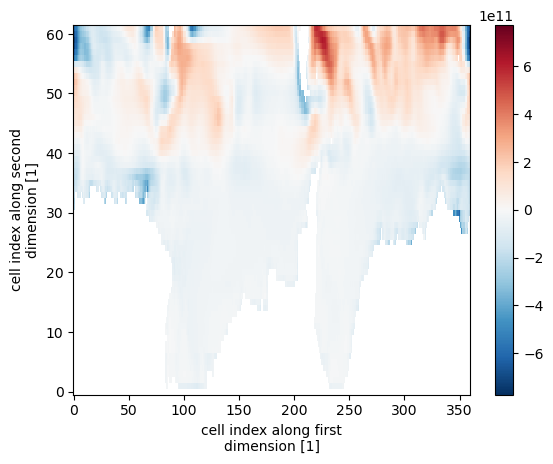

In [74]:
hfds_mean_w.plot()

In [57]:
# hfds_45S_200m_profile.plot()

# online data processing

In [11]:
def esgf_search(server="https://esgf-node.llnl.gov/esg-search/search",
                files_type="OPENDAP", local_node=True, project="CMIP6",
                verbose=False, format="application%2Fsolr%2Bjson",
                use_csrf=False, **search):
    client = requests.session()
    payload = search
    payload["project"] = project
    payload["type"]= "File"
    if local_node:
        payload["distrib"] = "false"
    if use_csrf:
        client.get(server)
        if 'csrftoken' in client.cookies:
            # Django 1.6 and up
            csrftoken = client.cookies['csrftoken']
        else:
            # older versions
            csrftoken = client.cookies['csrf']
        payload["csrfmiddlewaretoken"] = csrftoken

    payload["format"] = format

    offset = 0
    numFound = 10000
    all_files = []
    files_type = files_type.upper()
    while offset < numFound:
        payload["offset"] = offset
        url_keys = []
        for k in payload:
            url_keys += ["{}={}".format(k, payload[k])]

        url = "{}/?{}".format(server, "&".join(url_keys))
        print(url)
        r = client.get(url)
        r.raise_for_status()
        resp = r.json()["response"]
        numFound = int(resp["numFound"])
        resp = resp["docs"]
        offset += len(resp)
        for d in resp:
            if verbose:
                for k in d:
                    print("{}: {}".format(k,d[k]))
            url = d["url"]
            for f in d["url"]:
                sp = f.split("|")
                if sp[-1] == files_type:
                    all_files.append(sp[0].split(".html")[0])
    return sorted(all_files)

In [12]:
model = "CAS-ESM2-0"

result = esgf_search(
                    server= "https://esgf-node.llnl.gov/esg-search/search",
                    activity_id='CMIP', table_id='Omon', variable_id='thetao', experiment_id='historical',
                    # institution_id="NCAR",
                    source_id=model, member_id="r1i1p1f1")
result

https://esgf-node.llnl.gov/esg-search/search/?activity_id=CMIP&table_id=Omon&variable_id=thetao&experiment_id=historical&source_id=CAS-ESM2-0&member_id=r1i1p1f1&project=CMIP6&type=File&distrib=false&format=application%2Fsolr%2Bjson&offset=0


['http://esgf-data04.diasjp.net/thredds/dodsC/esg_dataroot/CMIP6/CMIP/CAS/CAS-ESM2-0/historical/r1i1p1f1/Omon/thetao/gn/v20201228/thetao_Omon_CAS-ESM2-0_historical_r1i1p1f1_gn_185001-189912.nc',
 'http://esgf-data04.diasjp.net/thredds/dodsC/esg_dataroot/CMIP6/CMIP/CAS/CAS-ESM2-0/historical/r1i1p1f1/Omon/thetao/gn/v20201228/thetao_Omon_CAS-ESM2-0_historical_r1i1p1f1_gn_190001-194912.nc',
 'http://esgf-data04.diasjp.net/thredds/dodsC/esg_dataroot/CMIP6/CMIP/CAS/CAS-ESM2-0/historical/r1i1p1f1/Omon/thetao/gn/v20201228/thetao_Omon_CAS-ESM2-0_historical_r1i1p1f1_gn_195001-201412.nc',
 'https://esg.iap.ac.cn/thredds/dodsC/esg_dataroot/CMIP6/CMIP/CAS/CAS-ESM2-0/historical/r1i1p1f1/Omon/thetao/gn/v20201228/thetao_Omon_CAS-ESM2-0_historical_r1i1p1f1_gn_185001-189912.nc',
 'https://esg.iap.ac.cn/thredds/dodsC/esg_dataroot/CMIP6/CMIP/CAS/CAS-ESM2-0/historical/r1i1p1f1/Omon/thetao/gn/v20201228/thetao_Omon_CAS-ESM2-0_historical_r1i1p1f1_gn_190001-194912.nc',
 'https://esg.iap.ac.cn/thredds/dodsC/esg

In [21]:
mask = ds.where(ds[lat_coord].compute() < -45).where(ds[lev_coord].compute() <lev_bound).compute()

In [ ]:
mask

In [13]:
# import xarray as xr
lev_bound = 500
# url = "https://esgf-node.llnl.gov/thredds/dodsC/cmip6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Omon/tos/gn/v20200701/tos_Omon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc"
files_to_open = result[0:3]
ds = xr.open_mfdataset(files_to_open, combine='by_coords', chunks={'time': 12})
ds = ds['thetao'].sel(time = slice('1979','2014'))
lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(ds)
mask = ds.where(ds[lat_coord].compute() < -45).where(ds[lev_coord].compute() <lev_bound).compute()

gg = ds.where(mask, drop =True).mean("time").compute()
thetao_45S_200m_profile = gg.mean(dim = "lon")
thetao_45S_200m_profile.to_netcdf(f"{base_data_dir}/{model}/thetao_45S_{lev_bound}m_profile_mean_{time_range.start}_{time_range.stop}.nc")

# ds.compute()
# print(ds)

In [ ]:
model_list_2

# Load and plot

In [18]:
model_list_2 = [
 'ACCESS-CM2',
 # 'CAS-ESM2-0',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 'CIESM',
 'CMCC-CM2-SR5',
 'CMCC-ESM2',
 'CNRM-CM6-1',
 'CNRM-ESM2-1',
 'FGOALS-f3-L',
 'FGOALS-g3',
 'IPSL-CM6A-LR',
 'IPSL-CM6A-LR-INCA',
 'MPI-ESM-1-2-HAM',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 # 'MRI-ESM2-0',
 # 'NorESM2-LM',
 # 'NorESM2-MM',
 'UKESM1-0-LL'
]

model_list_3 = [
 'ACCESS-CM2',
 'CAS-ESM2-0',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 'CIESM',
 'CMCC-CM2-SR5',
 'CMCC-ESM2',
 'CNRM-CM6-1',
 'CNRM-ESM2-1',
 'FGOALS-f3-L',
 'FGOALS-g3',
 'IPSL-CM6A-LR',
 'IPSL-CM6A-LR-INCA',
 # 'MPI-ESM-1-2-HAM',
 # 'MPI-ESM1-2-HR',
 # 'MPI-ESM1-2-LR',
 # 'MRI-ESM2-0',
 'NorESM2-LM',
 'NorESM2-MM',
 'UKESM1-0-LL'
]
base_data_dir = '/g/data/jk72/zc0441/Subject_2/data/'
time_range = slice('1979','2014')

In [38]:
# model =  'CMCC-CM2-SR5'
# model = 'ACCESS-CM2'
# model = 'CESM2'
# model = 'FGOALS-f3-L'
# model = 'CNRM-ESM2-1'
model = 'MPI-ESM-1-2-HAM'


thetao_45S_200m_profile = xr.open_dataarray(f"{base_data_dir}/{model}/thetao_45S_200m_profile_mean_{time_range.start}_{time_range.stop}.nc")

In [16]:

cmip6 = intake.open_esm_datastore("/g/data/dk92/catalog/v2/esm/cmip6-oi10/catalog.json")

constraints = dict(
    experiment_id="historical",
    variable_id="thetao",
    member_id=["r1i1p1f1"],
    table_id="Omon"
)

# Build your Ztake
zt_thetao_hist = Ztake(cmip6_catalog=cmip6, constraints= constraints,
           prefer_members=("r1i1p1f1","r1i1p1f2"),
           # prefer_grids=("gn", "gr","gr1")
           prefer_grids=("gr", "gn","gr1")
          )

In [28]:
# zt_thetao_hist.open_model('NorESM2-LM')["thetao"]

In [8]:
# thetao[lat_coord].compute()

In [189]:
# thetao.where(thetao[lat_coord].compute() < -45, drop = True)

In [74]:
# model = "CAS-ESM2-0"
# model ="NorESM2-LM"
model ="NorESM2-MM"

thetao = zt_thetao_hist.open_model(model)['thetao'].sel(time = slice('1979','2014'))

# xr.open_mfdataset(files_to_open, combine='by_coords')


# thetao = ds['thetao'].sel(time = slice('1979','2014')).compute()
# thetao = gg #ds['thetao'].sel(time = slice('1979','2014')).compute()

lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(thetao)
j_dim, i_dim = get_j_i_dims(thetao)
# j_dim, i_dim = lat_coord, lon_coord 
lev_bound = 200
if 'CESM' in model:
    lev_bound = 20000
thetao_45S_200m = thetao.where(thetao[lat_coord].compute() < -45, drop = True).where(thetao[lev_coord].compute() <lev_bound, drop = True)
thetao_45S_200m = thetao_45S_200m.chunk({'time': 10}) 

thetao_45S_200m_profile = thetao_45S_200m.mean(dim = ['time', i_dim]).compute()
thetao_45S_200m_profile[lat_coord] = thetao_45S_200m[lat_coord][:, 0]
thetao_45S_200m_profile.to_netcdf(f"{base_data_dir}/{model}/thetao_45S_200m_profile_mean_{time_range.start}_{time_range.stop}.nc")
print(f'{model} done')

NorESM2-MM done


In [ ]:
# CMIP6.CMIP.CAS.CAS-ESM2-0.historical.r1i1p1f1.Omon.thetao.gn

In [86]:
# result = esgf_search(
#                     server= "https://esgf-node.ornl.gov/esg-search/search",
#                     activity_id='CMIP', table_id='Omon', variable_id='thetao', experiment_id='historical',
#                     # institution_id="NCAR",
#                     source_id="CAS-ESM2-0", member_id="r1i1p1f1")
# result



In [ ]:
nodes = ["https://esgf.nci.org.au/esg-search/search",
        "https://esgf-node.ipsl.upmc.fr/esg-search/search"]

https://esgf-node.llnl.gov/esg-search/search/?activity_id=CMIP&table_id=Omon&variable_id=thetao&experiment_id=historical&source_id=CAS-ESM2-0&member_id=r1i1p1f1&project=CMIP6&type=File&distrib=false&format=application%2Fsolr%2Bjson&offset=0


['http://esgf-data04.diasjp.net/thredds/dodsC/esg_dataroot/CMIP6/CMIP/CAS/CAS-ESM2-0/historical/r1i1p1f1/Omon/thetao/gn/v20201228/thetao_Omon_CAS-ESM2-0_historical_r1i1p1f1_gn_185001-189912.nc',
 'http://esgf-data04.diasjp.net/thredds/dodsC/esg_dataroot/CMIP6/CMIP/CAS/CAS-ESM2-0/historical/r1i1p1f1/Omon/thetao/gn/v20201228/thetao_Omon_CAS-ESM2-0_historical_r1i1p1f1_gn_190001-194912.nc',
 'http://esgf-data04.diasjp.net/thredds/dodsC/esg_dataroot/CMIP6/CMIP/CAS/CAS-ESM2-0/historical/r1i1p1f1/Omon/thetao/gn/v20201228/thetao_Omon_CAS-ESM2-0_historical_r1i1p1f1_gn_195001-201412.nc',
 'https://esg.iap.ac.cn/thredds/dodsC/esg_dataroot/CMIP6/CMIP/CAS/CAS-ESM2-0/historical/r1i1p1f1/Omon/thetao/gn/v20201228/thetao_Omon_CAS-ESM2-0_historical_r1i1p1f1_gn_185001-189912.nc',
 'https://esg.iap.ac.cn/thredds/dodsC/esg_dataroot/CMIP6/CMIP/CAS/CAS-ESM2-0/historical/r1i1p1f1/Omon/thetao/gn/v20201228/thetao_Omon_CAS-ESM2-0_historical_r1i1p1f1_gn_190001-194912.nc',
 'https://esg.iap.ac.cn/thredds/dodsC/esg

In [132]:
# ds["thetao"]

In [ ]:
# ds.sel(time = slice('1979','1980'))['thetao']

In [133]:
gg = ds['thetao'].sel(time = slice('1979','2014')).where(thetao[lat_coord] < -45, drop = True).where(thetao[lev_coord] <lev_bound, drop = True).mean("time").compute()

In [147]:
model

'CAS-ESM2-0'

In [ ]:
thetao_45S_200m_profile = gg.mean(dim = "lon")

thetao_45S_200m_profile.to_netcdf(f"{base_data_dir}/{model}/thetao_45S_200m_profile_mean_{time_range.start}_{time_range.stop}.nc")


In [151]:
f"{base_data_dir}/{model}/thetao_45S_200m_profile_mean_{time_range.start}_{time_range.stop}.nc"

'/g/data/jk72/zc0441/Subject_2/data//CAS-ESM2-0/thetao_45S_200m_profile_mean_1979_2014.nc'

In [156]:
thetao_45S_200m_profile = gg.mean(dim = "lon").compute()
thetao_45S_200m_profile.to_netcdf(f"{base_data_dir}/{model}/thetao_45S_200m_profile_mean_{time_range.start}_{time_range.stop}.nc")

In [153]:
# thetao_45S_200m_profile.to_netcdf(f"{base_data_dir}/{model}/thetao_45S_200m_profile_mean_{time_range.start}_{time_range.stop}.nc")

In [99]:
thetao = ds.sel(time = slice('1979','1980'))['thetao'].mean("time").compute()

In [39]:
# thetao.mean(dim = "lon").plot()

In [140]:
# ds.sel(time = "2000-01")["thetao"].plot()
# thetao

In [105]:
# import intake
# col_url = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
# col = intake.open_esm_datastore(col_url)

In [106]:
# cat = col.search(source_id='CAS-ESM2-0', experiment_id='historical', variable_id='thetao')
# ds_dict = cat.to_dataset_dict(zarr_kwargs={'use_cftime': True})
# ds = list(ds_dict.values())[0]

# print(ds)

In [ ]:
# ds['thetao'].sel(time = slice('1979','2014'))

In [73]:
model = "CAS-ESM2-0"
# model = "Nor-"

# ds = xr.open_mfdataset(files_to_open, combine='by_coords')


# thetao = ds['thetao'].sel(time = slice('1979','2014')).compute()
thetao = gg #ds['thetao'].sel(time = slice('1979','2014')).compute()

lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(thetao)
# j_dim, i_dim = get_j_i_dims(thetao)
j_dim, i_dim = lat_coord, lon_coord 
lev_bound = 200
if 'CESM' in model:
    lev_bound = 20000
# thetao_45S_200m = thetao.where(thetao[lat_coord] < -45, drop = True).where(thetao[lev_coord] <lev_bound, drop = True)
# thetao_45S_200m = thetao_45S_200m.chunk({'time': 10}) 

thetao_45S_200m_profile = thetao_45S_200m.mean(dim = ['time', i_dim]).compute()
thetao_45S_200m_profile[lat_coord] = thetao_45S_200m[lat_coord][:, 0]
thetao_45S_200m_profile.to_netcdf(f"{base_data_dir}/{model}/thetao_45S_200m_profile_mean_{time_range.start}_{time_range.stop}.nc")
print(f'{model} done')

NameError: name 'gg' is not defined

In [58]:
# zt_thetao_hist._model_list

In [9]:
# thetao_45S_200m_profile.where(thetao_45S_200m_profile.latitude < 45, drop = True)

In [25]:
def plot_profile(model, thetao_45S_200m_profile):
    fig, ax = plt.subplots(figsize=(20, 10))
    
    lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(thetao_45S_200m_profile)
    
    # Set up x, y, and z
    x = thetao_45S_200m_profile[lat_coord]
    y = thetao_45S_200m_profile[lev_coord]
    if model == 'CIESM':
        x = get_lat_profile(model)
        thetao_45S_200m_profile = thetao_45S_200m_profile[:, :65]
    X, Y = np.meshgrid(x, y)
    z = thetao_45S_200m_profile.values
    
    # Define levels from -3 to 10 with step 0.5
    levels = np.arange(-2, 10.5, 0.5)
    
    # Plot
    cf = ax.contourf(X, Y, z, levels=levels, cmap='viridis', extend='both')
    fig.colorbar(cf, ax=ax, label='Temperature (°C)')
    
    # Add 0°C contour line
    c0 = ax.contour(X, Y, z, levels=[0], colors='white', linewidths=2)
    ax.clabel(c0, fmt='%d°C', colors='white', fontsize=10)
    
    # Labels and title
    ax.set_xlim(-80,-50)
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Depth (lev)')
    ax.set_title(f'{model} potential T over south 45°S, 200m Profile ')
    plt.gca().invert_yaxis()

# plt.show()


In [158]:
# thetao_45S_200m_profile 

In [10]:
# model
# # thetao_mean_lev_lat
# # thetao_mean_lev.mean()
# # thetao_45S_200m_profile[lat_coord].diff(dim = j_dim)
# thetao_mean_lev
# thetao_45S_200m_profile 

In [49]:
# thetao_45S_200m_profile[lat_coord]

In [50]:
# thetao_45S_200m_profile #[lat_coord].diff(dim = j_dim)

In [11]:
# model

In [19]:
model_list_simass = ['CESM2-FV2',
 'IPSL-CM6A-LR',
 'CESM2-WACCM-FV2',
 'IPSL-CM6A-LR-INCA',
 'CESM2-WACCM',
 'CESM2',
 'NorESM2-LM',
 'UKESM1-0-LL',
 'NorESM2-MM',
 'ACCESS-CM2',
 'CMCC-ESM2',
 'CMCC-CM2-SR5',
 'CIESM',
 'CNRM-CM6-1',
 'CNRM-ESM2-1']

total_mass_list = [ 8154.95748413, 10307.69065591,  7868.57174919, 10187.21467577,
        8588.06198626,  7786.5550537 ,  4877.70362688,  9780.66380895,
        5235.40568316,  5698.54489159,  6115.64795619,  5999.51740921,
        3688.97801218,  4105.43280515,  3037.84593772]

mass_da = xr.DataArray(
    total_mass_list,
    coords={'model': model_list_simass},
    dims=['model'],
    name='total_sea_ice_mass_gt'
)

In [20]:
thetao_list = []
# for model in model_list_3:
for model in model_list_simass:
    
    # thetao_45S_200m_profile = xr.open_dataarray(f"{base_data_dir}/{model}/thetao_45S_200m_profile_mean_{time_range.start}_{time_range.stop}.nc")
    thetao_45S_200m_profile = xr.open_dataarray(f"{base_data_dir}/{model}/thetao_45S_500m_profile_mean_{time_range.start}_{time_range.stop}.nc")
    
    
    # thetao_mean = thetao_45S_200m_profile.mean().values
    if "CAS" in model:
        lat_coord = "lat"
        lon_coord = "lon"
        lev_coord = "lev"
    else:    
        lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(thetao_45S_200m_profile)
    dataset = thetao_45S_200m_profile
    j_dim = (
        'j' if 'j' in dataset.dims else
        'y' if 'y' in dataset.dims else
        'nlat' if 'nlat' in dataset.dims else None
    )

    # lev_max= 500
    # lev_min= 200
    lev_max= 200
    lev_min= 0
    if "CESM" in model:
        lev_max= lev_max * 100
        lev_min= lev_min * 100
    # mask = thetao_45S_200m_profile[lat_coord] < -55 & thetao_45S_200m_profile[lev] < 500
    
    thetao_45S_200m_profile =thetao_45S_200m_profile.where(thetao_45S_200m_profile[lat_coord] < -50).where(thetao_45S_200m_profile[lev_coord] < lev_max).where(thetao_45S_200m_profile[lev_coord] > lev_min)
    # thetao_mean = thetao_45S_200m_profile.weighted(thetao_45S_200m_profile[lev_coord]).mean().values
    # thetao_mean = thetao_45S_200m_profile.mean().values
    
    
    thetao_mean_lev = thetao_45S_200m_profile.weighted(thetao_45S_200m_profile[lev_coord].diff(dim = lev_coord)).mean(dim = lev_coord)
    if "CNRM" in model or "IPSL" in model:
        thetao_mean_lev_lat= thetao_mean_lev[1:].weighted(thetao_45S_200m_profile[lat_coord].diff(dim = j_dim)).mean().values
    elif "CMCC" in model:
        thetao_mean_lev_lat= thetao_mean_lev.weighted(thetao_45S_200m_profile[lat_coord].diff(dim = 'i')).mean().values
    else:
        thetao_mean_lev_lat= thetao_mean_lev.weighted(thetao_45S_200m_profile[lat_coord].diff(dim = j_dim)).mean().values
        
    # lat = thetao_45S_200m_profile[lat_coord]
    # dlat = lat.diff(dim=j_dim)
    # # 把权重插回到原纬度点（简单处理）
    # w_lat = dlat.reindex({j_dim: lat}, method='nearest')
    
    # thetao_mean_lev_lat = thetao_mean_lev.weighted(w_lat).mean().values

    # lat_weight = thetao_45S_200m_profile[lat_coord].diff(dim=j_dim)
    # lat_weight = lat_weight.pad({j_dim: (0, 1)}, mode='edge')  # 补一个点，保持长度一致
    
    # thetao_mean_lev_lat = thetao_mean_lev.weighted(lat_weight).mean().values


    
    
    # print(f'{model}: {thetao_mean:.2f} °C')
    print(f'{model}: {thetao_mean_lev_lat:.2f} °C')
    thetao_list.append(thetao_mean_lev_lat)
    

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


CESM2-FV2: 0.96 °C
IPSL-CM6A-LR: 0.81 °C
CESM2-WACCM-FV2: 1.08 °C
IPSL-CM6A-LR-INCA: 0.89 °C
CESM2-WACCM: 0.69 °C
CESM2: 0.76 °C
NorESM2-LM: 1.34 °C
UKESM1-0-LL: 0.90 °C
NorESM2-MM: 1.05 °C
ACCESS-CM2: 0.97 °C
CMCC-ESM2: 0.91 °C
CMCC-CM2-SR5: 0.92 °C
CIESM: 1.47 °C
CNRM-CM6-1: 0.92 °C
CNRM-ESM2-1: 1.29 °C


In [21]:
thetao_da = xr.DataArray(
    thetao_list,
    coords={'model': model_list_simass},
    dims=['model'],
    name='mean_thetao'
)

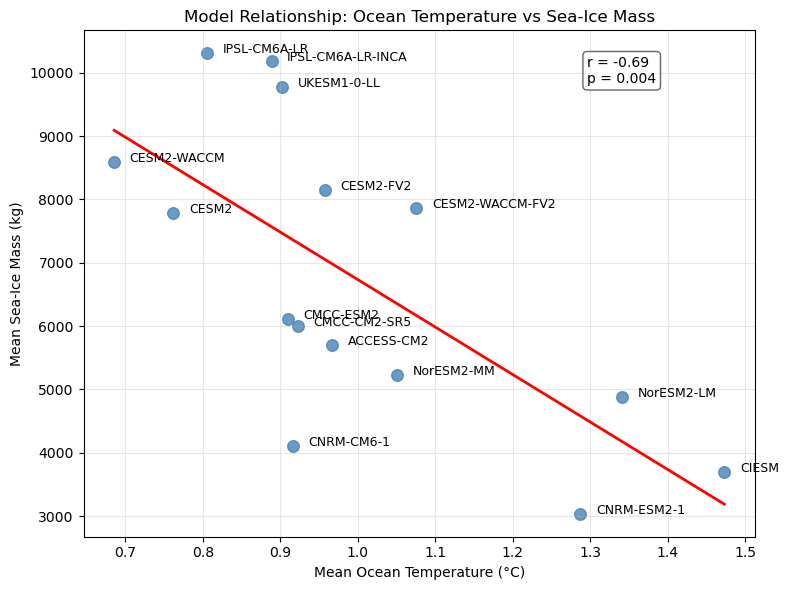

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Align to ensure matching model coordinates
thetao_da, mass_da = xr.align(thetao_da, mass_da)

# Extract model names and values
models = thetao_da["model"].values
thetao_vals = thetao_da.values
mass_vals = mass_da.values

# Remove NaNs safely
mask = np.isfinite(thetao_vals) & np.isfinite(mass_vals)
thetao_vals = thetao_vals[mask]
mass_vals = mass_vals[mask]
models = models[mask]

# 1️⃣ Compute correlations
r, p = pearsonr(thetao_vals, mass_vals)
s, _ = spearmanr(thetao_vals, mass_vals)

# 2️⃣ Create scatter plot
plt.figure(figsize=(8,6))
plt.scatter(thetao_vals, mass_vals, s=70, color="steelblue", alpha=0.8)

# 3️⃣ Add model labels
for x, y, name in zip(thetao_vals, mass_vals, models):
    plt.text(x + 0.02, y, name, fontsize=9)

# 4️⃣ Add regression line
m, b = np.polyfit(thetao_vals, mass_vals, 1)
x_line = np.linspace(min(thetao_vals), max(thetao_vals), 100)
plt.plot(x_line, m*x_line + b, color="red", lw=2, label="Linear fit")

# 5️⃣ Add correlation stats text box
plt.text(0.75, 0.95,
         f"r = {r:.2f}\np = {p:.3f}",  # \nSpearman ρ = {s:.2f}
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.6))

# 6️⃣ Final styling
plt.xlabel("Mean Ocean Temperature (°C)")
plt.ylabel("Mean Sea-Ice Mass (kg)")
plt.title("Model Relationship: Ocean Temperature vs Sea-Ice Mass")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [24]:
# model_series_mass

<Axes: xlabel='Mean Ocean Temperature (°C)', ylabel='Mean Sea-Ice Mass (kg)'>

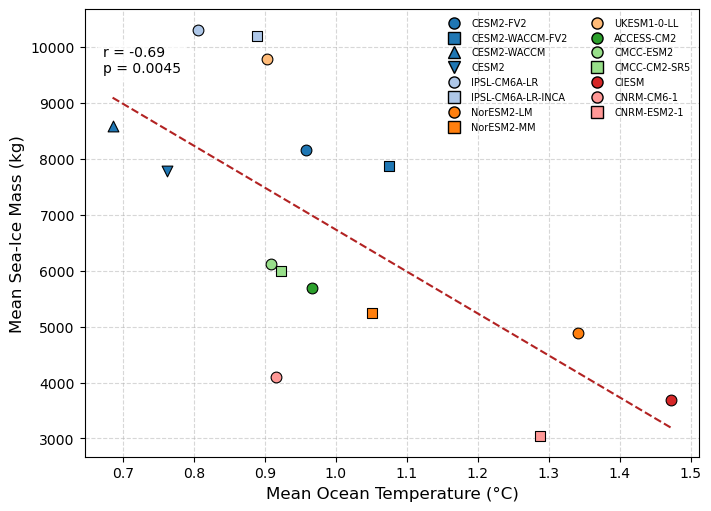

In [25]:
model_series_mass = {}
for model in model_list_simass:
    series = model.split('-')[0]  # Assuming the series is the part before the first '-'
    if series not in model_series_mass:
        model_series_mass[series] = []
    model_series_mass[series].append(model)
colors = plt.cm.tab20.colors

fig, ax = plt.subplots( figsize=(7, 5), constrained_layout=True)
# axs = axs.flatten()

plot_xy_grouped(
    x_da=thetao_da,          # must share the 'model' coord
    y_da=mass_da,
    model_series=model_series_mass,
    colors=colors,
    ax=ax,
    xlabel="Mean Ocean Temperature (°C)",               # your custom label
    ylabel="Mean Sea-Ice Mass (kg)"
)


In [202]:
model_list_2

['ACCESS-CM2',
 'CESM2',
 'CESM2-FV2',
 'CESM2-WACCM',
 'CESM2-WACCM-FV2',
 'CIESM',
 'CMCC-CM2-SR5',
 'CMCC-ESM2',
 'CNRM-CM6-1',
 'CNRM-ESM2-1',
 'FGOALS-f3-L',
 'FGOALS-g3',
 'IPSL-CM6A-LR',
 'IPSL-CM6A-LR-INCA',
 'MPI-ESM-1-2-HAM',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'UKESM1-0-LL']

In [36]:
# zt_thetao_hist.open_model(model)["thetao"]

In [44]:
# model = "CMCC-ESM2"
# # model = 'ACCESS-CM2'
model = 'FGOALS-g3'
xr.open_dataarray(f"{base_data_dir}/{model}/thetao_45S_500m_profile_mean_{time_range.start}_{time_range.stop}.nc") #.mean(dim = 'i').values

<xarray.DataArray 'thetao' (lev: 20, j: 70)> Size: 6kB
[1400 values with dtype=float32]
Coordinates:
  * lev        (lev) float64 160B 5.0 15.0 25.0 35.0 ... 178.4 222.5 303.1 432.6
  * j          (j) int32 280B 148 149 150 151 152 153 ... 213 214 215 216 217
    latitude   (j) float64 560B ...
    longitude  (j) float64 560B ...
    i          int32 4B ...

## sea ice mass vs temperature

In [26]:
import numpy as np
import xarray as xr

depth_levels = [5, 10,20,30, 40, 50, 60, 70,80,90, 100,120,140, 160,180, 200,250, 300,350, 400,450,500]
# Define latitude limits (south boundary first, north boundary second)
# lat_lim = [-60, -50]
lat_lim = [-75, -60]


# Apply selection using the limitsx
# da = da.where((da[lat_coord] > lat_lim[0]) & (da[lat_coord] < lat_lim[1]), drop=True)


per_model = []  # list of 1D DataArrays (depth) with a 'model' coord

for model in model_list_simass:
    da = xr.open_dataarray(
        f"{base_data_dir}/{model}/thetao_45S_500m_profile_mean_{time_range.start}_{time_range.stop}.nc"
    )

    # --- coordinate names ---
    if "CAS" in model:
        lat_coord, lon_coord, lev_coord = "lat", "lon", "lev"
    else:
        lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(da)

    # --- region filter (south of 50S) ---


    # Apply selection using the limits
    da = da.where((da[lat_coord] > lat_lim[0]) & (da[lat_coord] < lat_lim[1]), drop=True)


    # --- CESM depth units (cm -> m), if applicable ---
    if "CESM" in model:
        da = da.assign_coords({lev_coord: da[lev_coord] / 100.0})

    # --- make lev monotonic increasing for interp ---
    if not np.all(np.diff(da[lev_coord].values) > 0):
        da = da.sortby(lev_coord)

    # --- limit to safe interp range (no extrapolation) ---
    lev_min = float(da[lev_coord].min())
    lev_max = float(da[lev_coord].max())
    levels_in_range = [d for d in depth_levels if lev_min <= d <= lev_max]
    if not levels_in_range:
        # skip if no target depths within model range
        continue

    # --- interpolate to requested depths ---
    da_i = da.interp({lev_coord: levels_in_range})

    # --- reduce over non-depth dims (prefer a lat-like dim if present) ---
    j_dim = 'j' if 'j' in da_i.dims else ('y' if 'y' in da_i.dims else ('nlat' if 'nlat' in da_i.dims else None))
    if "CMCC" in model:
        j_dim = 'i'  # model-specific quirk you mentioned

    # start with all non-depth dims
    reduce_dims = [d for d in da_i.dims if d != lev_coord]
    if j_dim in reduce_dims:
        da_mean = da_i.mean(dim=j_dim)
        reduce_dims = [d for d in reduce_dims if d != j_dim]
    # average remaining dims (e.g., x/i/nlon/time) if any
    da_mean = da_mean.mean(dim=reduce_dims) if reduce_dims else (da_i if 'da_mean' not in locals() else da_mean)

    # --- standardize to full depth set, fill missing with NaN ---
    da_mean = da_mean.reindex({lev_coord: depth_levels})

    # --- keep ONLY the depth coordinate before concat ---
    da_mean = da_mean.rename({lev_coord: "depth"})
    
    # remove all non-index coords (e.g., lat/lon/time/aux coords)
    da_mean = da_mean.reset_coords(drop=True)
    
    # ensure depth is the sole coordinate and 1-D
    da_mean = da_mean.assign_coords(depth=("depth", da_mean["depth"].values))
    
    # (optional) enforce ordering
    da_mean = da_mean.transpose("depth")
    
    # attach model dim and prep for concat
    da_mean = da_mean.expand_dims(model=[model]).transpose("model", "depth")
    per_model.append(da_mean)


    # per_model.append(da_mean)

# --- concatenate into (model, depth) ---
if per_model:
    thetao_all = xr.concat(per_model, dim="model")
    thetao_all.name = "thetao_mean"

    # optional: dataset wrapper
    ds = thetao_all.to_dataset()

    # across-model stats (by depth)
    thetao_mean_across_models = thetao_all.mean(dim="model", skipna=True)
    thetao_std_across_models  = thetao_all.std(dim="model",  skipna=True)
    thetao_count              = xr.apply_ufunc(np.isfinite, thetao_all).sum(dim="model")

#     # quick peek
#     print(thetao_all)                    # DataArray (model, depth)
#     print(thetao_mean_across_models)     # mean vs depth
#     print(thetao_std_across_models)      # std vs depth
#     print(thetao_count)                  # valid model count per depth

#     # optional save
#     # ds.to_netcdf(f"{out_dir}/thetao_mean_by_depth_{time_range.start}_{time_range.stop}.nc")
# else:
#     print("No models produced data within the requested depth levels.")


In [27]:
# thetao_all.

In [28]:

# 1) align on the intersecting set of models
thetao_all_aligned, mass_da_aligned = xr.align(thetao_all, mass_da, join="inner")

# 2) broadcast mass to (model, depth)
mass_b = mass_da_aligned.broadcast_like(thetao_all_aligned)  # dims: (model, depth)

# 3) correlation across models at each depth
r_by_depth = xr.corr(thetao_all_aligned, mass_b, dim="model")
r_by_depth.name = "corr(thetao, mass)"
print(r_by_depth)         # dims: (depth,)


<xarray.DataArray 'corr(thetao, mass)' (depth: 22)> Size: 176B
array([-0.72972354, -0.72869239, -0.76861385, -0.81438184, -0.80302086,
       -0.73236157, -0.61409788, -0.49861566, -0.43058562, -0.41074649,
       -0.44703691, -0.45852612, -0.2949497 , -0.19455594, -0.13988767,
       -0.10991286, -0.0859354 , -0.09086213, -0.10201022, -0.118163  ,
       -0.13667104, -0.15473025])
Coordinates:
  * depth    (depth) int64 176B 5 10 20 30 40 50 60 ... 250 300 350 400 450 500


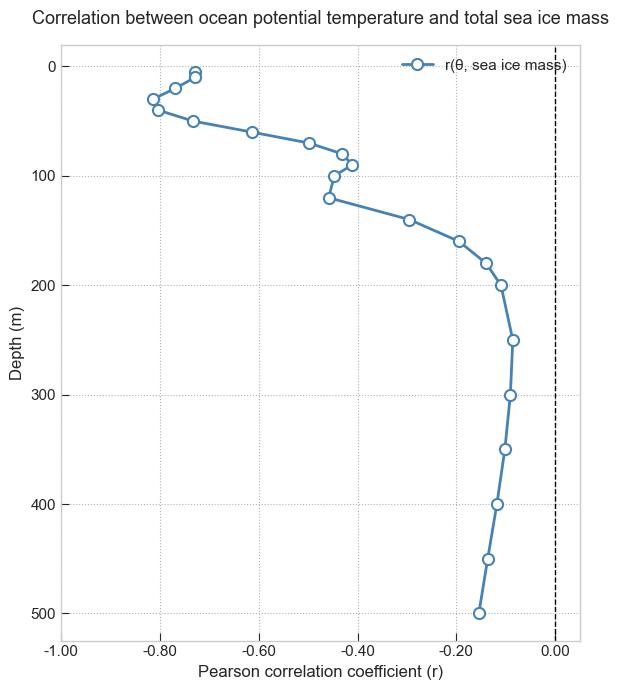

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: use a clean scientific style
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(6, 7))

# Plot with smooth line and markers
ax.plot(
    r_by_depth,
    r_by_depth.depth,
    marker='o',
    markersize=8,
    linewidth=2,
    color='steelblue',
    markerfacecolor='white',
    markeredgewidth=1.5,
    label='r(θ, sea ice mass)'
)

# Reverse y-axis so depth increases downward
ax.invert_yaxis()

ax.set_xlim(-1,0.05)
# Labels and title
ax.set_xlabel('Pearson correlation coefficient (r)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_title('Correlation between ocean potential temperature and total sea ice mass', fontsize=13, pad=15)

# Scientific-style ticks and limits
ax.tick_params(axis='both', which='major', labelsize=11, direction='in', length=6)
ax.tick_params(axis='both', which='minor', direction='in', length=3)
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

# Add a zero line for visual reference
ax.axvline(0, color='k', linestyle='--', linewidth=1)

# Add subtle gridlines
ax.grid(True, linestyle=':', color='0.7')

# Optional legend
ax.legend(frameon=False, fontsize=11, loc='upper right')

# Tight layout for better spacing
plt.tight_layout()
plt.show()


In [30]:
import numpy as np
import xarray as xr

# --- config ---
depth_levels = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90,
                100, 120, 140, 160, 180, 200, 250, 300, 350, 400, 450, 500]
# latitude window and 2° bins
lat_lim = [-79.5, -49.5]
lat_step = 1.0
lat_bins = np.arange(lat_lim[0], lat_lim[1] + lat_step, lat_step)  # [-80, -78, ..., -52, -50]
lat_labels = [f"{lat_bins[i]}:{lat_bins[i+1]}" for i in range(len(lat_bins)-1)]

per_model = []  # list of DataArrays with dims (lat_bin, depth), plus coord model

for model in model_list_simass:
    da = xr.open_dataarray(
        f"{base_data_dir}/{model}/thetao_45S_500m_profile_mean_{time_range.start}_{time_range.stop}.nc"
    )

    # --- coordinate names ---
    if "CAS" in model:
        lat_coord, lon_coord, lev_coord = "lat", "lon", "lev"
    else:
        lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(da)

    # --- select latitude range ---
    da = da.where((da[lat_coord] > lat_lim[0]) & (da[lat_coord] < lat_lim[1]), drop=True)

    # --- CESM depth units (cm -> m), if applicable ---
    if "CESM" in model:
        da = da.assign_coords({lev_coord: da[lev_coord] / 100.0})

    # --- lev monotonic for interp ---
    if not np.all(np.diff(da[lev_coord].values) > 0):
        da = da.sortby(lev_coord)

    # --- safe interp range (avoid extrapolation) ---
    lev_min = float(da[lev_coord].min())
    lev_max = float(da[lev_coord].max())
    levels_in_range = [d for d in depth_levels if lev_min <= d <= lev_max]
    if not levels_in_range:
        continue

    # --- interpolate to requested depths (keep latitude dim!) ---
    da_i = da.interp({lev_coord: levels_in_range})

    # --- pick latitude-like dim name if needed elsewhere ---
    j_dim = 'j' if 'j' in da_i.dims else ('y' if 'y' in da_i.dims else ('nlat' if 'nlat' in da_i.dims else None))
    if "CMCC" in model and j_dim is None and 'i' in da_i.dims:
        j_dim = 'i'

    # ensure lat coord is monotonic for binning/interp safety
    if not np.all(np.diff(da_i[lat_coord].values) > 0):
        da_i = da_i.sortby(lat_coord)

    # --- bin by latitude bands and average within each band ---
    # This reduces the native lat dimension while creating a new '<lat_coord>_bins' coord
    da_binned = da_i.groupby_bins(
        da_i[lat_coord], bins=lat_bins, labels=lat_labels, right=False
    ).mean()

    # da_binned dims are: (lev, <lat_coord>_bins) (+ any leftover dims if present)
    # Reduce any remaining non-depth, non-bin dims (e.g., x/nlon/time)
    reduce_dims = [d for d in da_binned.dims if d not in (lev_coord, f"{lat_coord}_bins")]
    if reduce_dims:
        da_binned = da_binned.mean(dim=reduce_dims)

    # --- standardize coords for concat: rename lev->depth, lat bins -> 'lat_bin' ---
    da_binned = da_binned.rename({lev_coord: "depth", f"{lat_coord}_bins": "lat_bin"})
    # ensure full target depth axis
    da_binned = da_binned.reindex({"depth": depth_levels})

    # keep ONLY coords we need
    da_binned = da_binned.reset_coords(drop=True)
    da_binned = da_binned.assign_coords(depth=("depth", da_binned["depth"].values))
    da_binned = da_binned.assign_coords(lat_bin=("lat_bin", da_binned["lat_bin"].values))

    # final ordering and add model coord
    da_binned = da_binned.transpose("lat_bin", "depth")
    da_binned = da_binned.expand_dims(model=[model]).transpose("model", "lat_bin", "depth")

    per_model.append(da_binned)

# --- concatenate models: (model, lat_bin, depth) ---
if not per_model:
    raise RuntimeError("No models produced data within requested depth/latitude ranges.")

thetao_all_lat = xr.concat(per_model, dim="model")
thetao_all_lat.name = "thetao_mean"

# -----------------------------
# Correlation with mass at each (lat_bin, depth)
# -----------------------------
# mass_da: (model)
thetao_aligned, mass_aligned = xr.align(thetao_all_lat, mass_da, join="inner")
mass_b = mass_aligned.broadcast_like(thetao_aligned)  # (model, lat_bin, depth)

# correlation across models for each (lat_bin, depth)
r_by_lat_depth = xr.corr(thetao_aligned, mass_b, dim="model")
r_by_lat_depth.name = "corr(thetao, mass)"

print(r_by_lat_depth)   # dims: (lat_bin, depth)

# Example: extract a latitude band
# r_by_lat_depth.sel(lat_bin="-70.0:-65.0")


<xarray.DataArray 'corr(thetao, mass)' (lat_bin: 30, depth: 22)> Size: 5kB
array([[            nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan],
       [-5.33247227e-01, -5.65780341e-01, -6.15973981e-01,
        -6.39865571e-01, -6.47652119e-01, -6.54077141e-01,
        -6.70863817e-01, -6.88618818e-01, -6.99167337e-01,
        -7.00940527e-01, -6.84699370e-01, -6.05185668e-01,
        -4.94244248e-01, -3.73841086e-01, -2.85767141e-01,
        -2.43070620e-01, -2.42118167e-01, -3.04107949e-01,
        -3.75633756e-01, -4.18860249e-01, -4.31037157e-01,
        -4.37265780e-01],
       [-6.81615649e-01, -7.14585171e-01, -7.99

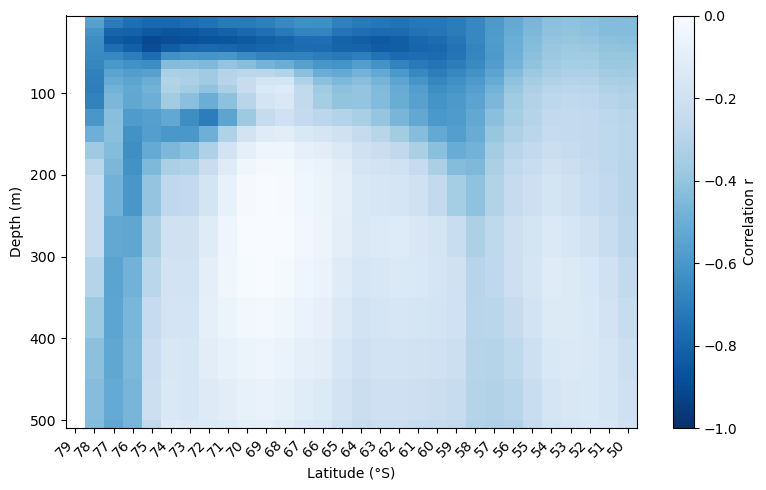

In [31]:
import matplotlib.pyplot as plt
plt.style.use('default')      # Reset to default Matplotlib style
fig, ax = plt.subplots(figsize=(8, 5))
# Limit correlation range (typically -1 to 0 for your case)
vmin, vmax = -1, 0
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# Use a blue colormap (e.g., 'Blues', 'Blues_r', or 'ocean_r')
im = ax.pcolormesh(
    np.arange(r_by_lat_depth.sizes["lat_bin"] + 1),
    np.append(r_by_lat_depth.depth.values, r_by_lat_depth.depth.values[-1] + 10),
    r_by_lat_depth.T.values,
    shading="auto",
    cmap="Blues_r",   # reverse so darker = stronger (more negative)
    norm=norm
)
ax.invert_yaxis()
# ax.set_xticks(np.arange(len(r_by_lat_depth.lat_bin)) + 0.5)
# ax.set_xticklabels(r_by_lat_depth.lat_bin.values, rotation=45, ha='right')

lat_centers = [abs(np.mean([float(a.split(':')[0]), float(a.split(':')[1])])) 
               for a in r_by_lat_depth.lat_bin.values]
ax.set_xticks(np.arange(len(lat_centers)) + 0.5)
ax.set_xticklabels([f"{lc:.0f}" for lc in lat_centers], rotation=45, ha='right')
ax.set_xlabel("Latitude (°S)")

ax.set_ylabel("Depth (m)")
# ax.set_xlabel("Latitude band")
cbar = plt.colorbar(im, ax=ax, label="Correlation r")
plt.savefig('t_correlation.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


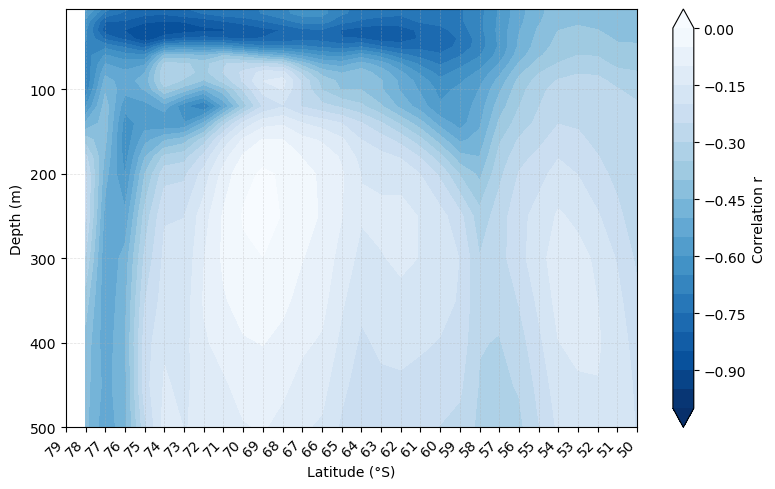

In [32]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plt.style.use('default')  # Reset to default Matplotlib style

fig, ax = plt.subplots(figsize=(8, 5))

# Correlation range
vmin, vmax = -1, 0
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# ---- Coordinates for contourf (must be centers, not edges) ----
x = np.arange(len(r_by_lat_depth.lat_bin)) + 0.5
y = r_by_lat_depth.depth.values
X, Y = np.meshgrid(x, y)

# ---- Contour levels ----
levels = np.linspace(vmin, vmax, 21)

# ---- Contourf plot ----
cf = ax.contourf(
    X,
    Y,
    r_by_lat_depth.T.values,
    levels=levels,
    cmap="Blues_r",   # darker = stronger (more negative)
    norm=norm,
    extend="both"
)

# Invert depth axis
ax.invert_yaxis()

# ---- Latitude labels ----
lat_centers = [
    abs(np.mean([float(a.split(':')[0]), float(a.split(':')[1])]))
    for a in r_by_lat_depth.lat_bin.values
]

ax.set_xticks(x)
ax.set_xticklabels([f"{lc:.0f}" for lc in lat_centers], rotation=45, ha='right')
ax.set_xlabel("Latitude (°S)")
ax.set_ylabel("Depth (m)")
# ---- Grid ----
ax.grid(
    which="both",
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)
# ---- Colorbar ----
cbar = plt.colorbar(cf, ax=ax, label="Correlation r")

plt.tight_layout()
plt.savefig("t_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


## sea ice and hfds

In [33]:
# areacello * hfds_mean
# New grid Southern Ocean 1 degree[]
new_lat_values = np.arange(-89, -30, 1)
new_lon_values = np.arange(0, 360, 1)
ds_out_so1 = xr.Dataset({'lat': (['lat'], new_lat_values),
                            'lon': (['lon'], new_lon_values)})


In [34]:
net_hfds_list = []
hfds_list = []
tos_mean_list = []

for model in model_list_simass:
    
    hfds_mean = xr.open_dataset(
        f"{base_data_dir}/{model}/hfds_45S_mean_{time_range.start}_{time_range.stop}.nc"
    )['hfds']
    
    areacello = xr.open_dataset(
        f"{base_data_dir}/{model}/areacello_historical_gn.nc"
    )['areacello']
    
    tos_monthly = xr.open_dataset(
        f"{base_data_dir}/{model}/temperature_monthly_mean_{time_range.start}_{time_range.stop}.nc"
    )['tos']
    
    lat_coord, lon_coord = get_lat_lon_coords(hfds_mean)

    # --- mask Southern Ocean ---
    mask = hfds_mean[lat_coord] < -50
    
    hfds_mean = hfds_mean.where(mask)
    areacello_so = areacello.where(mask)

    # ============================
    # 1) Net hfds (already OK)
    # ============================
    hfds_mean_w = hfds_mean * areacello_so
    net_hfds = hfds_mean_w.sum().values.item()

    # ============================
    # 2) Area-weighted mean T south of 50S
    # ============================
    tos_mean = tos_monthly.mean('month')

    tos_so = tos_mean.where(mask)

    tos_weighted_mean = (
        (tos_so * areacello_so).sum()
        /
        areacello_so.sum()
    ).values.item()

    # ============================
    # 3) Store results
    # ============================
    net_hfds_list.append(net_hfds)
    hfds_list.append(hfds_mean)
    tos_mean_list.append(tos_weighted_mean)


In [35]:
data_dict = {}
# Loop through each model in model_list
for model in model_list_1:
    # Construct file paths for each variable
    file_paths = {
        # "density": f"{base_data_dir}/{model}/density_climatology_mean_{time_range.start}_{time_range.stop}.nc",
        # "density_monthly": f"{base_data_dir}/{model}/density_monthly_mean_{time_range.start}_{time_range.stop}.nc",
        # "sid_weighted_monthly": f"{base_data_dir}/{model}/sidmassth_climatology_weighted_monthly_{time_range.start}_{time_range.stop}.nc",
        # "sidd_weighted_monthly": f"{base_data_dir}/{model}/sidmassdyn_monthly_weighted_{time_range.start}_{time_range.stop}.nc",
        # "sos_monthly": f"{base_data_dir}/{model}/salinity_monthly_mean_{time_range.start}_{time_range.stop}.nc",
        "tos_monthly": f"{base_data_dir}/{model}/temperature_monthly_mean_{time_range.start}_{time_range.stop}.nc",      
        "hfds_mean": f"{base_data_dir}/{model}/hfds_45S_mean_{time_range.start}_{time_range.stop}.nc",
        # "sid_melt": f"{base_data_dir}/{model}/sidmassth_melt_climatology_weighted_monthly_{time_range.start}_{time_range.stop}.nc",
    }
    # Ensure the dictionary has an entry for the model
    if model not in data_dict:
        data_dict[model] = {}

    # Load each dataset if the file exists
    for var, file_path in file_paths.items():
        if os.path.exists(file_path):
            try:
                data = xr.open_dataarray(file_path)  # Use open_dataset() if multiple variables exist
                data_dict[model][var] = data  # Store in dictionary
                if var == "sidd_weighted_monthly":
                    data_dict[model]['sidd_export'] = data.where(data<0)
                    data_dict[model]['sidd_import'] = data.where(data>0)
                    
                print(f"✅ Successfully loaded {var} for model: {model}")
            except Exception as e:
                print(f"⚠️ Error loading {var} for model {model}: {e}")
        else:
            print(f"❌ File not found: {file_path}")


✅ Successfully loaded tos_monthly for model: ACCESS-CM2
✅ Successfully loaded hfds_mean for model: ACCESS-CM2
✅ Successfully loaded tos_monthly for model: CAS-ESM2-0
✅ Successfully loaded hfds_mean for model: CAS-ESM2-0
✅ Successfully loaded tos_monthly for model: CESM2
✅ Successfully loaded hfds_mean for model: CESM2
✅ Successfully loaded tos_monthly for model: CESM2-FV2
✅ Successfully loaded hfds_mean for model: CESM2-FV2
✅ Successfully loaded tos_monthly for model: CESM2-WACCM
✅ Successfully loaded hfds_mean for model: CESM2-WACCM
✅ Successfully loaded tos_monthly for model: CESM2-WACCM-FV2
✅ Successfully loaded hfds_mean for model: CESM2-WACCM-FV2
✅ Successfully loaded tos_monthly for model: CIESM
✅ Successfully loaded hfds_mean for model: CIESM
✅ Successfully loaded tos_monthly for model: CMCC-CM2-SR5
✅ Successfully loaded hfds_mean for model: CMCC-CM2-SR5
✅ Successfully loaded tos_monthly for model: CMCC-ESM2
✅ Successfully loaded hfds_mean for model: CMCC-ESM2
✅ Successfully loa

In [36]:
# data_dict[model]["tos_monthly"]

In [37]:
# net_hfds_list = []
# hfds_list = []

# for model in model_list_simass:
#     hfds_mean = data_dict[model]["hfds_mean"]['hfds']
#     tos_mean = data_dict[model]["tos_monthly"]

#     # areacello = xr.open_dataset(f"{base_data_dir}/{model}/areacello_historical_gn.nc")['areacello']
#     lat_coord, lon_coord = get_lat_lon_coords(hfds_mean)
#     hfds_mean = hfds_mean.where(hfds_mean[lat_coord] < -50)
    
#     new_lat_values = np.arange(-89, -30, 1)
#     new_lon_values = np.arange(0, 360, 1)
#     ds_out_so1 = xr.Dataset({'lat': (['lat'], new_lat_values),
#                                 'lon': (['lon'], new_lon_values)})

    
#     # hfds_mean_w = hfds_mean * areacello
#     # net_hfds = hfds_mean_w.sum().values.item()
#     # net_hfds_list.append(net_hfds)
#     # hfds_list.append(hfds_mean)

In [38]:
    # regridder_hfds = xe.Regridder(
    #     hfds_src,
    #     ds_out_so1,
    #     "bilinear",
    #     periodic=True,
    #     # reuse_weights=True,
    #     # filename=f"regridder_hfds_{model}.nc",
    # )

In [39]:
import xarray as xr
import numpy as np
import xesmf as xe

# -------------------------------------------------------------------
# 1. Define common Southern Ocean 1° grid
# -------------------------------------------------------------------
new_lat_values = np.arange(-89, -30, 1)    # -89 … -31
new_lon_values = np.arange(0, 360, 1)      # 0 … 359

ds_out_so1 = xr.Dataset(
    {
        "lat": (["lat"], new_lat_values),
        "lon": (["lon"], new_lon_values),
    }
)

# Lists to store regridded fields
hfds_rg_list = []
tos_rg_list = []
valid_models = []

# --- 用 CESM2 的 POP 网格当参考（给 CESM2-FV2 继承）---
cesm2_fg  = data_dict["CESM2"]["hfds_mean"]
cesm2_lat = cesm2_fg["lat"]
cesm2_lon = cesm2_fg["lon"]


# -------------------------------------------------------------------
# 2. Loop over models: mask to SO, regrid hfds & tos to common grid
# -------------------------------------------------------------------
for model in model_list_simass:
    # --- hfds ---
    hfds = data_dict[model]["hfds_mean"] #["hfds"]
    lat_hfds, lon_hfds = get_lat_lon_coords(hfds)

    # Southern Ocean mask
    # hfds = hfds.where(hfds[lat_hfds] < -50)

    # Rename to standard lat/lon for xESMF
    hfds_src = hfds.rename({lat_hfds: "lat", lon_hfds: "lon"})



    # --- tos (monthly -> mean) ---
    tos = data_dict[model]["tos_monthly"].mean("month")
    lat_tos, lon_tos = get_lat_lon_coords(tos)
    tos = tos.where(tos[lat_tos] < -50)
    tos_src = tos.rename({lat_tos: "lat", lon_tos: "lon"})
    
    if model == "CESM2-FV2":
        hfds_src = hfds_src.assign_coords(lat=cesm2_lat, lon=cesm2_lon)
        tos_src = tos_src.assign_coords(lat=cesm2_lat, lon=cesm2_lon)


    # --- Regridders (one for hfds, one for tos – grids may differ) ---
    # filename+reuse_weights keep things efficient if you re-run
    regridder_hfds = xe.Regridder(
        hfds_src,
        ds_out_so1,
        "bilinear",
        periodic=True,
        ignore_degenerate=True,
        # filename=f"regridder_hfds_{model}.nc",
    )

    regridder_tos = xe.Regridder(
        tos_src,
        ds_out_so1,
        "bilinear",
        periodic=True,
        ignore_degenerate=True,
        # filename=f"regridder_tos_{model}.nc",
    )

    # Apply regridding
    hfds_rg = regridder_hfds(hfds_src)
    tos_rg = regridder_tos(tos_src)

    # Make sure they have a consistent name if needed
    hfds_rg = hfds_rg.rename("hfds")
    tos_rg = tos_rg.rename("tos")

    hfds_rg_list.append(hfds_rg)
    tos_rg_list.append(tos_rg)
    valid_models.append(model)

# -------------------------------------------------------------------
# 3. Stack into model dimension
# -------------------------------------------------------------------
hfds_all = xr.concat(hfds_rg_list, dim="model").assign_coords(model=("model", valid_models))
tos_all = xr.concat(tos_rg_list, dim="model").assign_coords(model=("model", valid_models))

# Optionally ensure consistent mask (NaNs in either are NaNs in both)
mask = np.isfinite(hfds_all) & np.isfinite(tos_all)
hfds_all = hfds_all.where(mask)
tos_all = tos_all.where(mask)

# -------------------------------------------------------------------
# 4. Inter-model correlation: r(hfds, tos) at each grid point
# -------------------------------------------------------------------
# correlation across models at each lat,lon
r_map = xr.corr(hfds_all, tos_all, dim="model")
r_map.name = "r_hfds_tos"

# r_map is now a 2D [lat, lon] correlation field
# Example plot:
# r_map.plot(vmin=-1, vmax=1, cmap="RdBu_r")


/g/data/jk72/zc0441/zpackage/ztake.py:717: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.10, 1, 1])


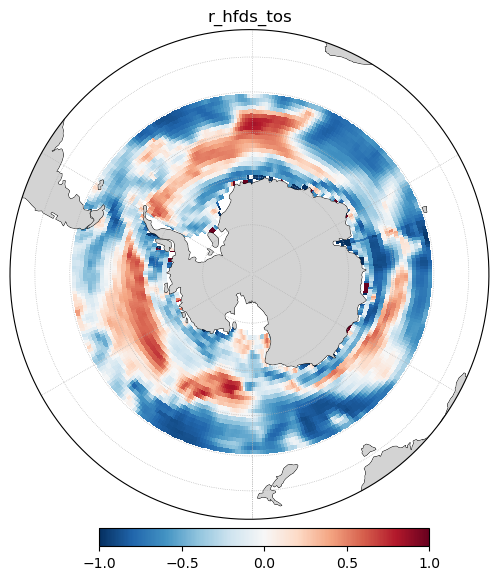

In [40]:
plot_south_polar_auto(r_map, cmap = 'RdBu_r')

In [41]:
import numpy as np
import xarray as xr

# --- config ---
# 和 thetao 那段保持一致：纬度范围、步长、标签格式
lat_lim   = [-79.5, -49.5]
lat_step  = 1.0
lat_bins  = np.arange(lat_lim[0], lat_lim[1] + lat_step, lat_step)  # [-80, -79, ..., -50]
lat_labels = [f"{lat_bins[i]}:{lat_bins[i+1]}" for i in range(len(lat_bins)-1)]

hfds_models = []  # 每个元素: DataArray (model, lat_bin)
tos_models  = []

# =========================
#   逐模型：纬度分箱 + 水平平均
# =========================
for model in model_list_simass:

    # ------------- HFDS ----------------
    # 假设 hfds_mean 是 Dataset，变量名叫 'hfds'
    hfds = data_dict[model]["hfds_mean"]
    lat_coord, lon_coord = get_lat_lon_coords(hfds)

    # 按纬度范围裁剪
    hfds = hfds.where(
        (hfds[lat_coord] > lat_lim[0]) & (hfds[lat_coord] < lat_lim[1]),
        drop=True
    )

    # 按纬度 bin 分组
    hfds_binned = hfds.groupby_bins(
        hfds[lat_coord],
        bins=lat_bins,
        labels=lat_labels,
        right=False,
    ).mean()

    # 此时 dims 类似：(<lat_coord>_bins, 其他水平维度，比如 lon/x/y)
    # 把所有非纬向维度都平均掉，只剩一个纬向剖面
    reduce_dims = [d for d in hfds_binned.dims if d != f"{lat_coord}_bins"]
    if reduce_dims:
        hfds_binned = hfds_binned.mean(dim=reduce_dims)

    # 标准化纬向维度名
    hfds_binned = hfds_binned.rename({f"{lat_coord}_bins": "lat_bin"})

    # 确保每个模型都有同一套 lat_bin（即使某些 bin 全是 NaN）
    hfds_binned = hfds_binned.reindex(lat_bin=lat_labels)

    # 干净一点：只保留 lat_bin 这一坐标
    hfds_binned = hfds_binned.reset_coords(drop=True)
    hfds_binned = hfds_binned.assign_coords(lat_bin=("lat_bin", hfds_binned["lat_bin"].values))

    # 变成 (model, lat_bin)
    hfds_binned = hfds_binned.expand_dims(model=[model]).transpose("model", "lat_bin")

    hfds_models.append(hfds_binned)

    # ------------- TOS ----------------
    # 先对 month 做平均
    tos = data_dict[model]["tos_monthly"].mean("month")
    lat_tos, lon_tos = get_lat_lon_coords(tos)

    tos = tos.where(
        (tos[lat_tos] > lat_lim[0]) & (tos[lat_tos] < lat_lim[1]),
        drop=True
    )

    tos_binned = tos.groupby_bins(
        tos[lat_tos],
        bins=lat_bins,
        labels=lat_labels,
        right=False,
    ).mean()

    reduce_dims_t = [d for d in tos_binned.dims if d != f"{lat_tos}_bins"]
    if reduce_dims_t:
        tos_binned = tos_binned.mean(dim=reduce_dims_t)

    tos_binned = tos_binned.rename({f"{lat_tos}_bins": "lat_bin"})
    tos_binned = tos_binned.reindex(lat_bin=lat_labels)
    tos_binned = tos_binned.reset_coords(drop=True)
    tos_binned = tos_binned.assign_coords(lat_bin=("lat_bin", tos_binned["lat_bin"].values))
    tos_binned = tos_binned.expand_dims(model=[model]).transpose("model", "lat_bin")

    tos_models.append(tos_binned)

# --- 如果一个模型都没留下，直接报错 ---
if not hfds_models or not tos_models:
    raise RuntimeError("No models produced data within requested latitude range.")

# =========================
#   拼成 (model, lat_bin) 并求相关
# =========================
hfds_all_lat = xr.concat(hfds_models, dim="model", coords="minimal")
hfds_all_lat.name = "hfds_lat_mean"

tos_all_lat  = xr.concat(tos_models,  dim="model", coords="minimal")
tos_all_lat.name  = "tos_lat_mean"

# 对齐（防止某些模型缺某些 bin）
hfds_aligned, tos_aligned = xr.align(hfds_all_lat, tos_all_lat, join="inner")

# 跨模型相关：对每个 lat_bin，算 r(model-wise)
r_by_lat = xr.corr(hfds_aligned, tos_aligned, dim="model")
r_by_lat.name = "corr(hfds, tos)"   # dims: (lat_bin,)

print(r_by_lat)
# e.g. 取某个纬度带：
# r_by_lat.sel(lat_bin="-70.0:-69.0")


<xarray.DataArray 'corr(hfds, tos)' (lat_bin: 30)> Size: 120B
array([-0.42469135, -0.06854951,  0.15428458,  0.0957048 ,  0.1921443 ,
        0.17535256, -0.0230739 , -0.20620392, -0.23185138, -0.33471295,
       -0.3857191 , -0.12097786,  0.11729714,  0.28521746,  0.5449154 ,
        0.6511473 ,  0.61652124,  0.5651708 ,  0.46589735,  0.49891806,
        0.43102372,  0.41717166,  0.2651131 ,  0.06955367, -0.13671009,
       -0.27990282, -0.30871177, -0.32951856, -0.36556476, -0.5901627 ],
      dtype=float32)
Coordinates:
  * lat_bin  (lat_bin) object 240B '-79.5:-78.5' '-78.5:-77.5' ... '-50.5:-49.5'


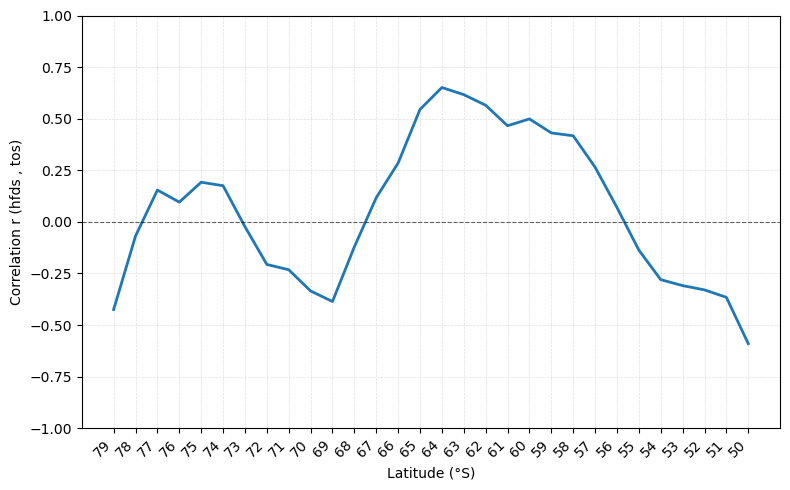

In [42]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')   # Reset to default Matplotlib style

fig, ax = plt.subplots(figsize=(8, 5))

# -----------------------------
#  Compute latitude centers
# -----------------------------
lat_centers = [
    abs(np.mean([float(a.split(':')[0]), float(a.split(':')[1])]))
    for a in r_by_lat.lat_bin.values
]

x = np.arange(len(lat_centers)) + 0.5   # center ticks

# -----------------------------
#  Plot line
# -----------------------------
ax.plot(
    x,
    r_by_lat.values,
    linewidth=2
)

# Zero line
ax.axhline(0, linestyle="--", linewidth=0.8, color="k", alpha=0.6)

# -----------------------------
#  X ticks = latitude centers
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{lc:.0f}" for lc in lat_centers],
    rotation=45,
    ha='right'
)

# -----------------------------
#  Axis labels
# -----------------------------
ax.set_xlabel("Latitude (°S)")
ax.set_ylabel("Correlation r (hfds , tos)")

# -----------------------------
#  Limits (optional)
# -----------------------------
ax.set_ylim(-1, 1)

# -----------------------------
#  Grid (same as contourf style)
# -----------------------------
ax.grid(
    which="both",
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

plt.tight_layout()
plt.savefig("hfds_tos_corr_lat_profile.png", dpi=300, bbox_inches="tight")
plt.show()


In [43]:
net_hfds_da = xr.DataArray(
    net_hfds_list,
    coords={'model': model_list_simass},
    dims=['model'],
    name='net_hfds'
)

# hfds_da = xr.DataArray(
#     hfds_list,
#     coords={'model': model_list_simass},
#     dims=['model'],
#     name='net_hfds'
# )

tos_mean_da = xr.DataArray(
    tos_mean_list,
    coords={'model': model_list_simass},
    dims=['model'],
    name='net_hfds'
)

In [44]:
# net_hfds_da

In [45]:
# mass_da

<Axes: xlabel='Net Heat flux (W)', ylabel='Sea ice mass (Gt)'>

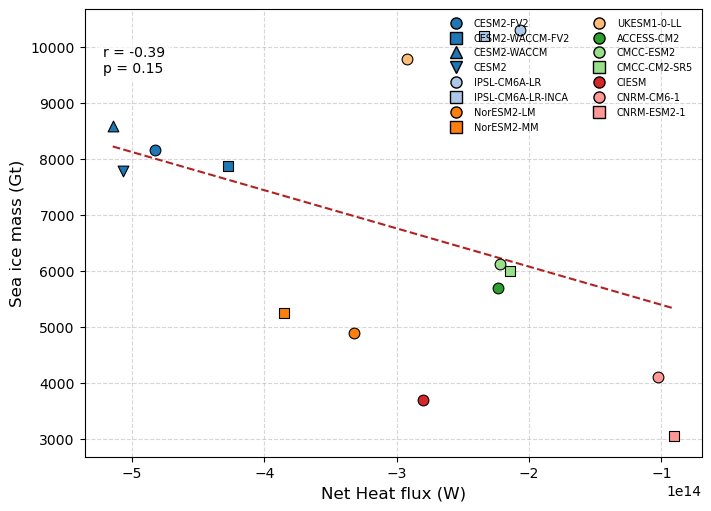

In [46]:
model_series_mass = {}
for model in model_list_simass:
    series = model.split('-')[0]  # Assuming the series is the part before the first '-'
    if series not in model_series_mass:
        model_series_mass[series] = []
    model_series_mass[series].append(model)
colors = plt.cm.tab20.colors

fig, ax = plt.subplots( figsize=(7, 5), constrained_layout=True)
# axs = axs.flatten()

plot_xy_grouped(
    x_da=net_hfds_da,          # must share the 'model' coord
    y_da=mass_da,
    # y_da=thetao_da,
    model_series=model_series_mass,
    colors=colors,
    ax=ax,
    xlabel="Net Heat flux (W)",               # your custom label
    ylabel="Sea ice mass (Gt)"
)


<Axes: xlabel='Net Heat flux (W)', ylabel='Mean temperature (°)'>

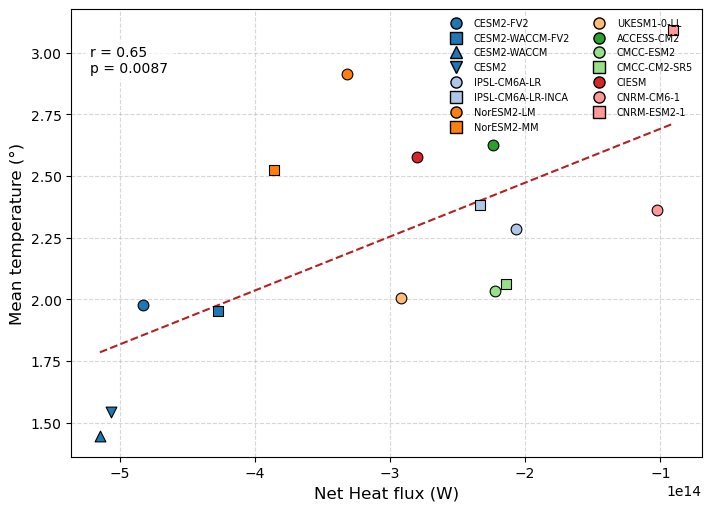

In [47]:
model_series_mass = {}
for model in model_list_simass:
    series = model.split('-')[0]  # Assuming the series is the part before the first '-'
    if series not in model_series_mass:
        model_series_mass[series] = []
    model_series_mass[series].append(model)
colors = plt.cm.tab20.colors

fig, ax = plt.subplots( figsize=(7, 5), constrained_layout=True)
# axs = axs.flatten()

plot_xy_grouped(
    x_da=net_hfds_da,          # must share the 'model' coord
    y_da=tos_mean_da,
    # y_da=thetao_da,
    model_series=model_series_mass,
    colors=colors,
    ax=ax,
    xlabel="Net Heat flux (W)",               # your custom label
    ylabel="Mean temperature (°)"
)


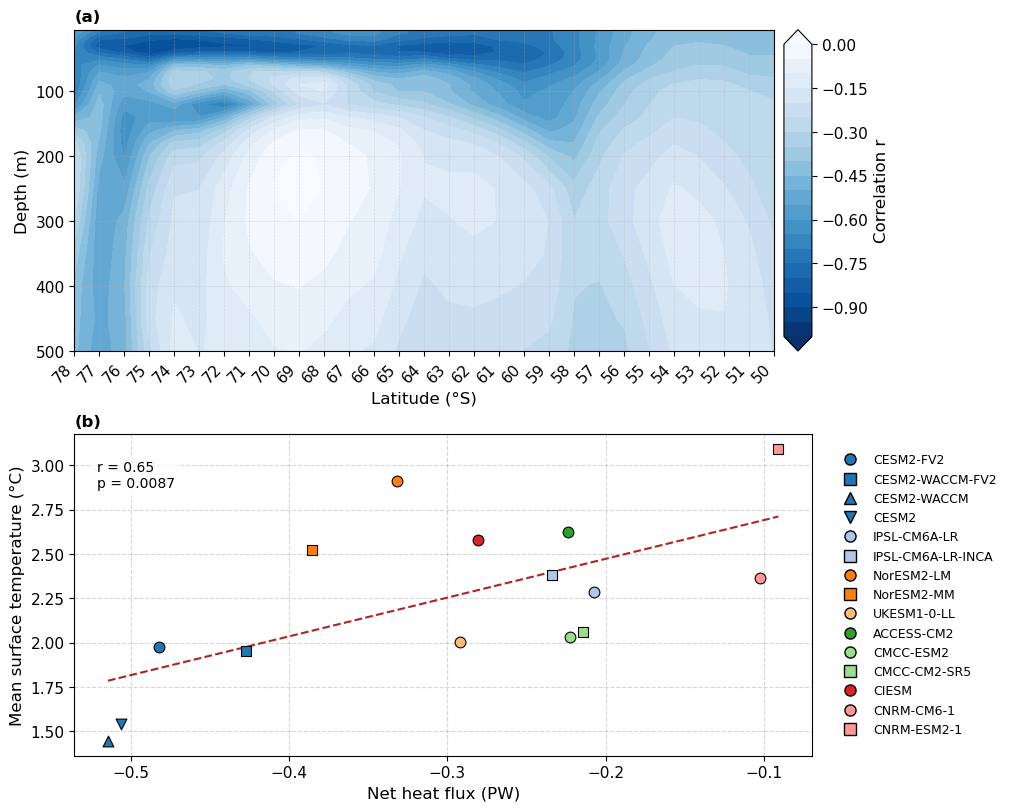

In [54]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from scipy.stats import pearsonr

plt.style.use('default')

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 12,
    "figure.titlesize": 12,
})


# =========================
#  Figure + Axes
# =========================
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    # gridspec_kw={'height_ratios': [2.2, 1.3]},
    constrained_layout=True
)

# =========================================================
#  PANEL 1 — contourf(r_by_lat_depth)
# =========================================================
# =========================================================
#  PANEL 1 — contourf(r_by_lat_depth)
# =========================================================
vmin, vmax = -1, 0
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# ===== 去掉第一列纬度 bin =====
r_plot = r_by_lat_depth.isel(lat_bin=slice(1, None))

# x 轴索引 (长度对应新的 lat_bin)
x = np.arange(len(r_plot.lat_bin)) + 0.5
y = r_plot.depth.values
X, Y = np.meshgrid(x, y)

levels = np.linspace(vmin, vmax, 21)

cf = ax1.contourf(
    X, Y,
    r_plot.T.values,
    levels=levels,
    cmap="Blues_r",
    norm=norm,
    extend="both"
)

ax1.invert_yaxis()

# 重新取纬度中心（注意也去掉第一列）
lat_centers = [
    abs(np.mean([float(a.split(':')[0]), float(a.split(':')[1])]))
    for a in r_plot.lat_bin.values
]

ax1.set_xticks(x)
ax1.set_xticklabels(
    [f"{lc:.0f}" for lc in lat_centers],
    rotation=45,
    ha='right'
)

ax1.set_xlabel("Latitude (°S)")
ax1.set_ylabel("Depth (m)")

ax1.grid(which="both", linestyle="--", linewidth=0.5, alpha=0.4)
# # ---------- Panel labels ----------
# ax1.text(0.02, 0.97, "(a)", transform=ax1.transAxes,
#          ha="left", va="top", fontsize=13, fontweight="bold")

from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="4%", pad=0.1)

cbar = fig.colorbar(cf, cax=cax, label="Correlation r")



# =========================================================
#  PANEL 2 — 手写版 scatter + 回归 + legend
# =========================================================

# --- 按前缀分 series ---
model_series_mass = {}
for model in model_list_simass:
    series = model.split('-')[0]
    model_series_mass.setdefault(series, []).append(model)

series_names = list(model_series_mass.keys())
colors = plt.cm.tab20.colors
series_colors = {s: colors[i % len(colors)] for i, s in enumerate(series_names)}

marker_cycle = ('o','s','^','v','D','P','X','*','h','+','x')
line_color = 'firebrick'

# --- 取所有模型的 x,y 并做整体相关 + 回归线 ---
models_all = [m for s in series_names for m in model_series_mass[s]]

net_hfds_da_PW = net_hfds_da/1e15
x_all = net_hfds_da_PW.sel(model=models_all).to_numpy()
y_all = tos_mean_da.sel(model=models_all).to_numpy()

mask = np.isfinite(x_all) & np.isfinite(y_all)
x_all = x_all[mask]
y_all = y_all[mask]
models_masked = [m for k, m in enumerate(models_all) if mask[k]]

# 回归线 + r, p 注释
if len(x_all) >= 2:
    m_fit, b_fit = np.polyfit(x_all, y_all, 1)
    xx = np.linspace(x_all.min(), x_all.max(), 200)
    yy = m_fit * xx + b_fit
    ax2.plot(xx, yy, color=line_color, linestyle='--', linewidth=1.5)

    r, p = pearsonr(x_all, y_all)
    ax2.text(
        0.03, 0.92,
        f'r = {r:.2f}\np = {p:.2g}',
        transform=ax2.transAxes,
        ha='left', va='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

# --- 逐 series / model 画点 + legend handle ---
legend_handles = []

for i, s in enumerate(series_names):
    col = series_colors[s]
    series_models = [m for m in model_series_mass[s] if m in models_masked]

    for j, m in enumerate(series_models):
        mk = marker_cycle[j % len(marker_cycle)]

        xi = float(net_hfds_da_PW.sel(model=m))
        yi = float(tos_mean_da.sel(model=m))

        ax2.scatter(
            xi, yi,
            s=60,
            facecolor=col,
            edgecolor='k',
            marker=mk,
            linewidth=0.8,
            zorder=3
        )

        # 每个 model 一个 legend entry
        legend_handles.append(
            plt.Line2D(
                [0], [0],
                marker=mk,
                color='w',
                markerfacecolor=col,
                markeredgecolor='k',
                markersize=8,
                label=m
            )
        )

# 轴标签
ax2.set_xlabel("Net heat flux (PW)", fontsize=12)
ax2.set_ylabel("Mean surface temperature (°C)", fontsize=12)

# 网格
ax2.grid(True, linestyle='--', alpha=0.5)
# ax2.grid(True, linestyle='--', alpha=0.5)

# # ---------- Panel labels ----------
# ax2.text(0.02, 0.97, "(b)", transform=ax2.transAxes,
#          ha="left", va="top", fontsize=13, fontweight="bold")

# Legend 放在右下角
ax2.legend(
    handles=legend_handles,
    fontsize=9,
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),   # <<< 图外右侧居中
    ncol=1
)

ax1.set_title("(a)", loc="left", fontweight="bold")
ax2.set_title("(b)", loc="left", fontweight="bold")

# =========================================================
#  SAVE & SHOW
# =========================================================
fig.savefig("combined_correlation_heatflux_temp.png", dpi=300, bbox_inches="tight")
plt.show()


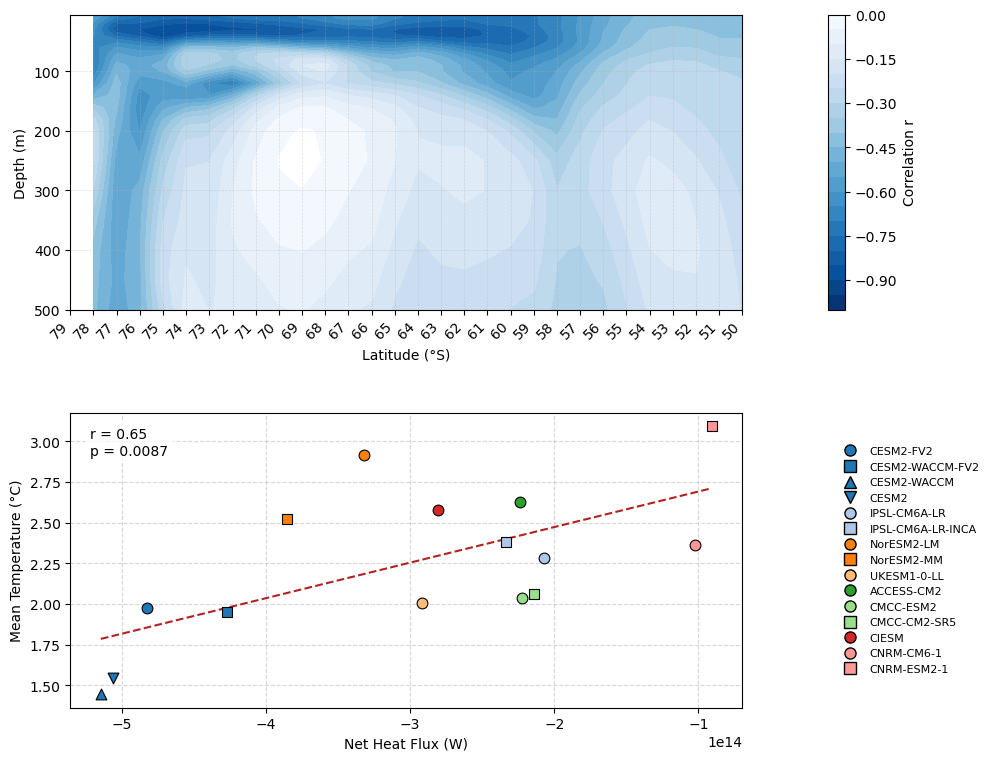

In [49]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from scipy.stats import pearsonr
from matplotlib.gridspec import GridSpec

plt.style.use('default')

# =========================
#  Figure + GridSpec Layout
# =========================
fig = plt.figure(figsize=(10, 9))

gs = GridSpec(
    2, 2,                  # 2 rows, 2 columns
    width_ratios=[12, 0.3],  # 左宽右窄
    height_ratios=[1, 1],
    wspace=0.25,
    hspace=0.35
)

ax1 = fig.add_subplot(gs[0, 0])   # Panel 1 主图
ax2 = fig.add_subplot(gs[1, 0])   # Panel 2 主图
cax = fig.add_subplot(gs[0, 1])   # Panel 1 colorbar
lax = fig.add_subplot(gs[1, 1])   # Panel 2 legend
lax.axis("off")

# =========================================================
#  PANEL 1 — contourf(r_by_lat_depth)
# =========================================================
vmin, vmax = -1, 0
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# x 轴是纬度 bin 索引（中心）
x = np.arange(len(r_by_lat_depth.lat_bin)) + 0.5
y = r_by_lat_depth.depth.values
X, Y = np.meshgrid(x, y)

levels = np.linspace(vmin, vmax, 21)

cf = ax1.contourf(
    X, Y,
    r_by_lat_depth.T.values,
    levels=levels,
    cmap="Blues_r",
    norm=norm,
    # extend="both"
)

ax1.invert_yaxis()

# 解析纬带字符串为中心纬度的绝对值
lat_centers = [
    abs(np.mean([float(a.split(':')[0]), float(a.split(':')[1])]))
    for a in r_by_lat_depth.lat_bin.values
]

ax1.set_xticks(x)
ax1.set_xticklabels(
    [f"{lc:.0f}" for lc in lat_centers],
    rotation=45,
    ha='right'
)

ax1.set_xlabel("Latitude (°S)")
ax1.set_ylabel("Depth (m)")

ax1.grid(which="both", linestyle="--", linewidth=0.5, alpha=0.4)

cbar = fig.colorbar(cf, cax=cax)
cbar.set_label("Correlation r")

# =========================================================
#  PANEL 2 — scatter: Net hfds vs mean tos
# =========================================================

# 按 model 前缀分系列
model_series_mass = {}
for model in model_list_simass:
    series = model.split('-')[0]
    model_series_mass.setdefault(series, []).append(model)

series_names = list(model_series_mass.keys())
colors = plt.cm.tab20.colors
series_colors = {s: colors[i % len(colors)] for i, s in enumerate(series_names)}
marker_cycle = ('o','s','^','v','D','P','X','*','h','+','x')
line_color = 'firebrick'

# 整体回归用所有模型
models_all = [m for s in series_names for m in model_series_mass[s]]

x_all = net_hfds_da.sel(model=models_all).to_numpy()
y_all = tos_mean_da.sel(model=models_all).to_numpy()

mask = np.isfinite(x_all) & np.isfinite(y_all)
x_all = x_all[mask]
y_all = y_all[mask]
models_masked = [m for k, m in enumerate(models_all) if mask[k]]

# 回归线 + r, p
if len(x_all) >= 2:
    m_fit, b_fit = np.polyfit(x_all, y_all, 1)
    xx = np.linspace(x_all.min(), x_all.max(), 200)
    yy = m_fit * xx + b_fit
    ax2.plot(xx, yy, color=line_color, linestyle='--', linewidth=1.5)

    r, p = pearsonr(x_all, y_all)
    ax2.text(
        0.03, 0.95,
        f'r = {r:.2f}\np = {p:.2g}',
        transform=ax2.transAxes,
        ha='left', va='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

# 画散点 + legend handles
legend_handles = []

for i, s in enumerate(series_names):
    col = series_colors[s]
    series_models = [m for m in model_series_mass[s] if m in models_masked]

    for j, m in enumerate(series_models):
        mk = marker_cycle[j % len(marker_cycle)]

        xi = float(net_hfds_da.sel(model=m))
        yi = float(tos_mean_da.sel(model=m))

        ax2.scatter(
            xi, yi,
            s=60,
            facecolor=col,
            edgecolor='k',
            marker=mk,
            linewidth=0.8,
            zorder=3
        )

        legend_handles.append(
            plt.Line2D(
                [0], [0],
                marker=mk,
                color='w',
                markerfacecolor=col,
                markeredgecolor='k',
                markersize=8,
                label=m
            )
        )

ax2.set_xlabel("Net Heat Flux (W)")
ax2.set_ylabel("Mean Temperature (°C)")
ax2.grid(True, linestyle='--', alpha=0.5)

# legend 放在右侧单独的 lax
if legend_handles:
    lax.legend(
        handles=legend_handles,
        loc="center left",
        fontsize=8,
        frameon=False
    )

# =========================================================
#  SAVE & SHOW
# =========================================================
fig.savefig("combined_correlation_heatflux_temp_aligned.png", dpi=300, bbox_inches="tight")
plt.show()


In [50]:
# mass_da: (model)
thetao_aligned, hfds_aligned = xr.align(thetao_all_lat, net_hfds_da, join="inner")
hfds_b = hfds_aligned.broadcast_like(hfds_aligned)  # (model, lat_bin, depth)

# correlation across models for each (lat_bin, depth)
r_by_lat_depth_hfds = xr.corr(thetao_aligned, hfds_b, dim="model")
r_by_lat_depth_hfds.name = "corr(thetao, hfds)"

print(r_by_lat_depth_hfds)   # dims: (lat_bin, depth)


<xarray.DataArray 'corr(thetao, hfds)' (lat_bin: 30, depth: 22)> Size: 5kB
array([[            nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan],
       [ 8.50953354e-01,  8.44496363e-01,  8.28805923e-01,
         8.27475586e-01,  8.00070447e-01,  7.55880068e-01,
         6.87228578e-01,  5.99922095e-01,  5.03459760e-01,
         3.87594992e-01,  2.52414904e-01, -3.94791711e-02,
        -2.81075355e-01, -4.53105537e-01, -5.45044096e-01,
        -5.77202793e-01, -5.43139404e-01, -4.05206253e-01,
        -2.06095677e-01, -1.17090771e-02,  1.19763974e-01,
         2.13821621e-01],
       [ 6.97746219e-01,  6.27464543e-01,  3.85

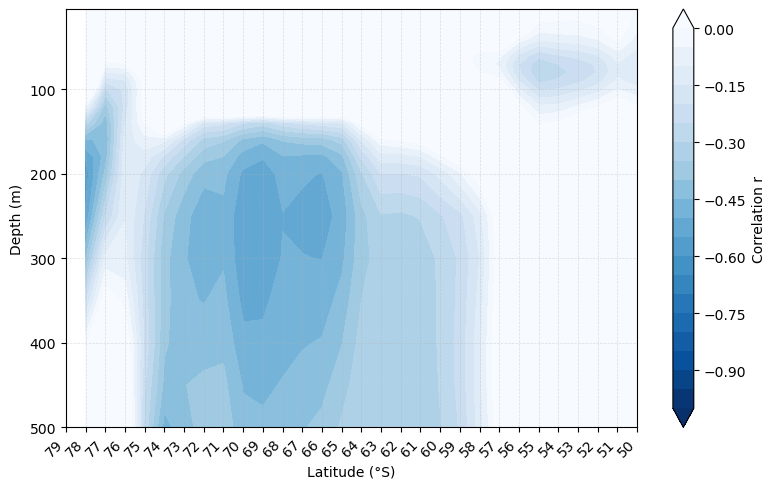

In [51]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plt.style.use('default')  # Reset to default Matplotlib style

fig, ax = plt.subplots(figsize=(8, 5))

# Correlation range
vmin, vmax = -1, 0
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# ---- Coordinates for contourf (must be centers, not edges) ----
x = np.arange(len(r_by_lat_depth.lat_bin)) + 0.5
y = r_by_lat_depth.depth.values
X, Y = np.meshgrid(x, y)

# ---- Contour levels ----
levels = np.linspace(vmin, vmax, 21)

# ---- Contourf plot ----
cf = ax.contourf(
    X,
    Y,
    r_by_lat_depth_hfds.T.values,
    levels=levels,
    cmap="Blues_r",   # darker = stronger (more negative)
    norm=norm,
    extend="both"
)

# Invert depth axis
ax.invert_yaxis()

# ---- Latitude labels ----
lat_centers = [
    abs(np.mean([float(a.split(':')[0]), float(a.split(':')[1])]))
    for a in r_by_lat_depth.lat_bin.values
]

ax.set_xticks(x)
ax.set_xticklabels([f"{lc:.0f}" for lc in lat_centers], rotation=45, ha='right')
ax.set_xlabel("Latitude (°S)")
ax.set_ylabel("Depth (m)")
# ---- Grid ----
ax.grid(
    which="both",
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)
# ---- Colorbar ----
cbar = plt.colorbar(cf, ax=ax, label="Correlation r")

plt.tight_layout()
plt.savefig("t_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


## profile 

In [71]:
model_list_sorted =['CESM2-FV2', 'IPSL-CM6A-LR', 'CESM2-WACCM-FV2',
       'IPSL-CM6A-LR-INCA', 'CESM2-WACCM', 'CESM2', 'NorESM2-LM',
       'UKESM1-0-LL', 'NorESM2-MM', 'FGOALS-g3', 'ACCESS-CM2',
       'CMCC-ESM2', 'CMCC-CM2-SR5', 'CIESM', 'FGOALS-f3-L', 'CAS-ESM2-0',
       'CNRM-CM6-1', 'CNRM-ESM2-1']

In [69]:
def plot_profile(model, thetao_45S_200m_profile, ax):
    if "CAS" in model:
        lat_coord = "lat"
        lon_coord = "lon"
        lev_coord = "lev"
    else:  
        lat_coord, lon_coord, lev_coord = get_lat_lon_lev_coords(thetao_45S_200m_profile)
    
    # Set up coordinates and values
    x = thetao_45S_200m_profile[lat_coord]
    y = thetao_45S_200m_profile[lev_coord]
    z = thetao_45S_200m_profile.values

    # Adjust depth unit for CESM
    if 'CESM2' in model:
        y = y / 100  # convert to meters if in cm

    # Handle special models
    if model == 'CIESM':
        thetao_45S_200m_profile = thetao_45S_200m_profile[:, :65]
        x = thetao_45S_200m_profile.latitude.values
    if 'MPI' in model:
        x = get_lat_profile(model)
        z = z[:, :np.size(x)]
    
    # Meshgrid for contour
    X, Y = np.meshgrid(x, y)
    levels = np.arange(-2, 10.5, 0.5)
    
    # Plot contour
    cf = ax.contourf(X, Y, z, levels=levels, cmap='jet', extend='both')
    
    # Add 0°C contour line
    c0 = ax.contour(X, Y, z, levels=[0], colors='white', linewidths=2)
    ax.clabel(c0, fmt='%d°C', colors='white', fontsize=9)

    # Axis limits and title
    ax.set_xlim(-80, -50)
    ax.set_title(f"{model}", fontsize=10)
    ax.set_ylim(0,500)
    ax.invert_yaxis()
    
    return cf


def plot_profiles(model_list, base_data_dir, time_range):
    save_path = 'tem_profile.png'
    n_plots = len(model_list)
    n_cols = 4
    n_rows = (n_plots // n_cols) + (n_plots % n_cols != 0)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols *4,n_rows *2.5), sharex=False, sharey=False)
    axes = axes.flatten()

    # Shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

    for i, model in enumerate(model_list):
        ax = axes[i]
        # Load data
        # da_path = f"{base_data_dir}/{model}/thetao_45S_200m_profile_mean_{time_range.start}_{time_range.stop}.nc"
        da_path = f"{base_data_dir}/{model}/thetao_45S_500m_profile_mean_{time_range.start}_{time_range.stop}.nc"
        
        thetao_45S_200m_profile = xr.open_dataarray(da_path)
        cf = plot_profile(model, thetao_45S_200m_profile, ax)
        
        
        # Only left column → ylabel
        if i % n_cols == 0:
            ax.set_ylabel('Depth (m)', fontsize=10)
        else:
            ax.set_ylabel('')
            # ax.set_yticklabels([])

        # Only bottom row → xlabel
        if i // n_cols == n_rows - 1:
            ax.set_xlabel('Latitude', fontsize=10)
        else:
            ax.set_xlabel('')
            # ax.set_xticklabels([])

    # Hide unused axes (if any)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Add colorbar
    fig.colorbar(cf, cax=cbar_ax, label='Temperature (°C)')
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


/jobfs/151747872.gadi-pbs/ipykernel_3386909/3900939258.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


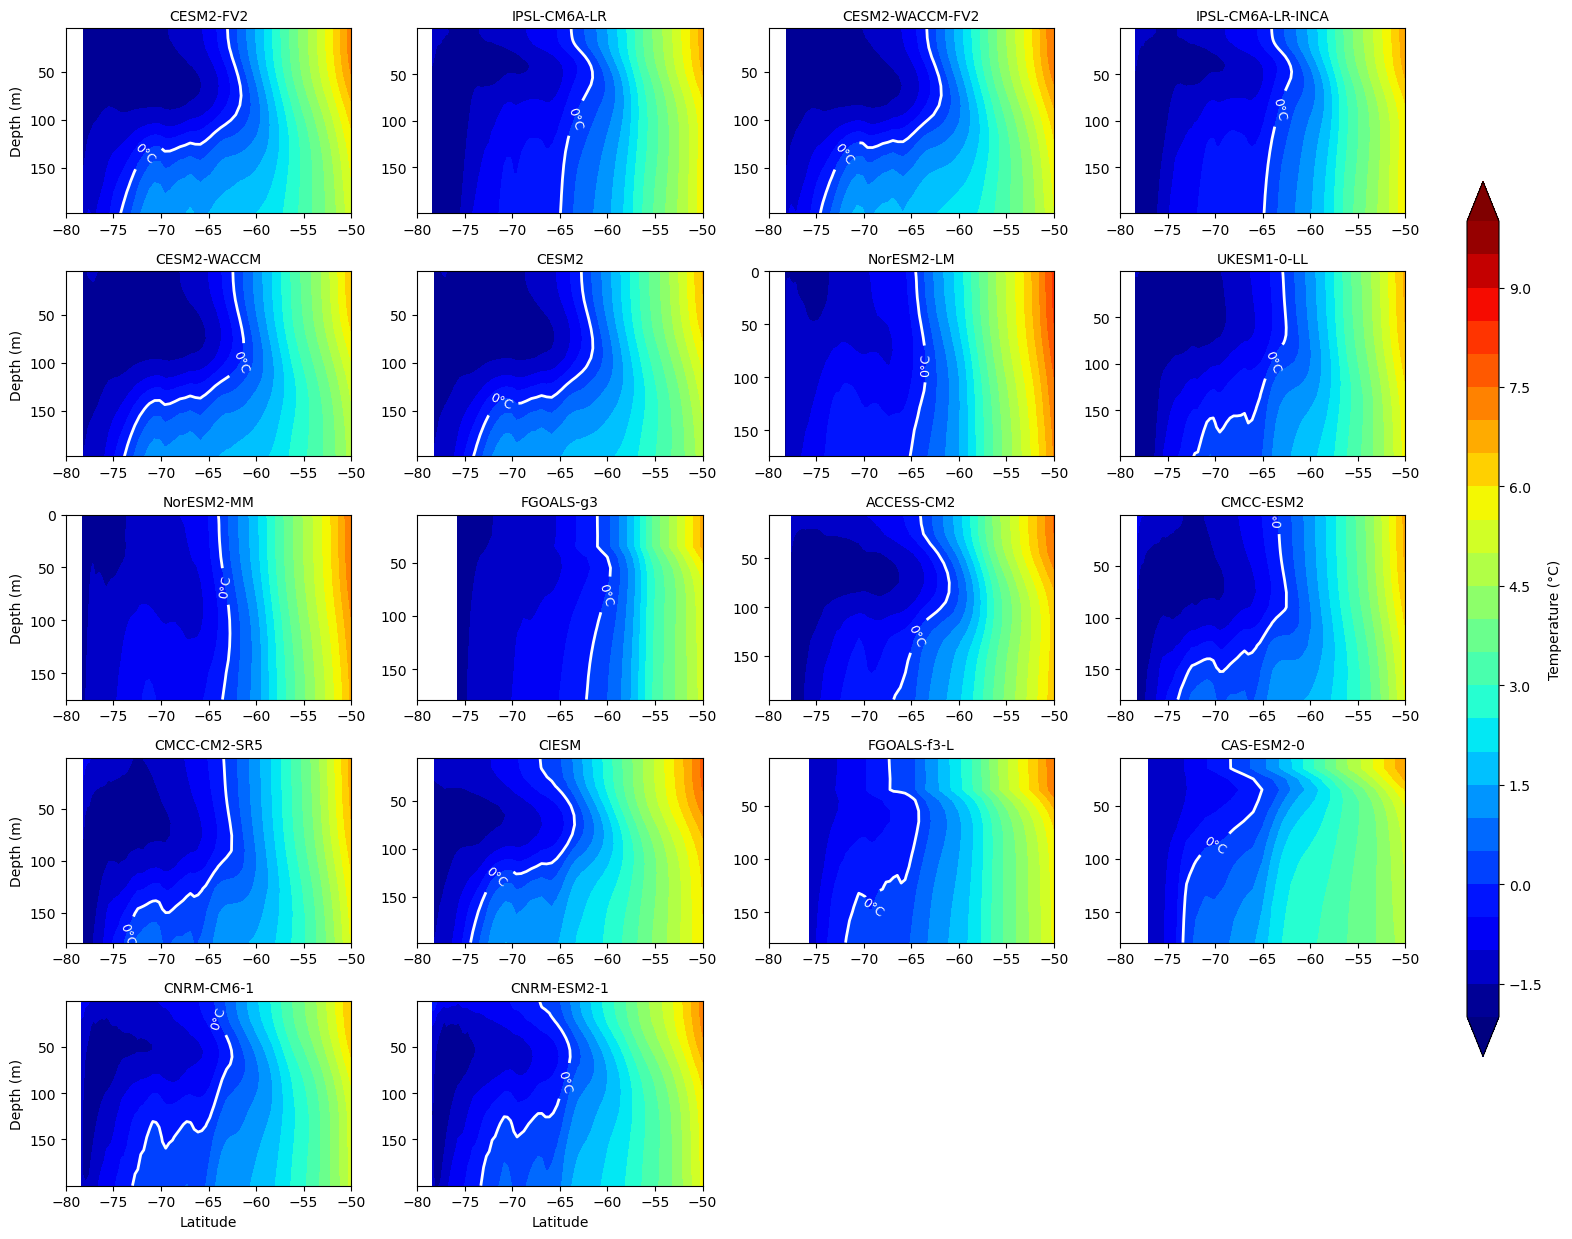

In [40]:
# plot_profiles(model_list_3, base_data_dir, time_range)
plot_profiles(model_list_sorted, base_data_dir, time_range)



/jobfs/154211754.gadi-pbs/ipykernel_1371027/1385433966.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


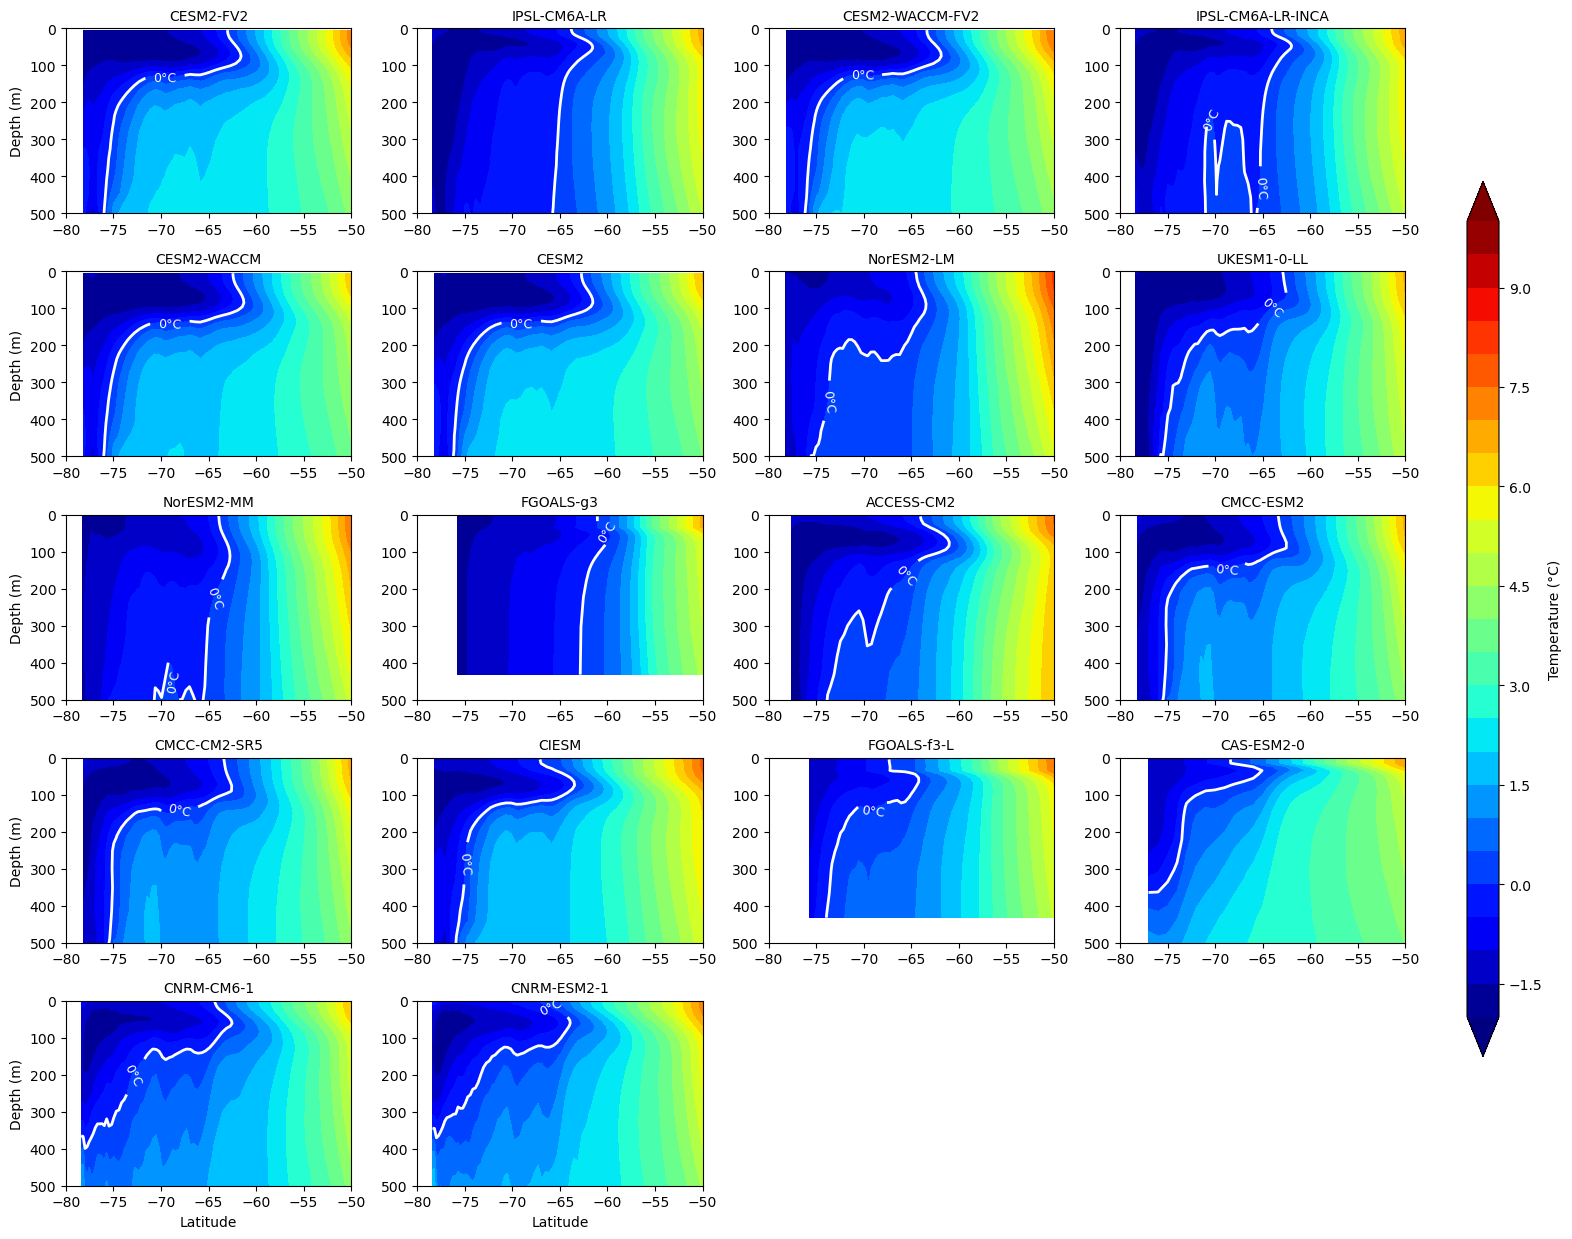

In [72]:
# plot_profiles(model_list_3, base_data_dir, time_range)
# plot_profiles(model_list_simass, base_data_dir, time_range)
plot_profiles(model_list_sorted, base_data_dir, time_range)




In [109]:
def regrid_to_common_grid_1d(data, target_lat, target_depth, model_name):
    # Detect coordinate names
    lat_name = [n for n in data.coords if 'lat' in n.lower()][0]
    depth_name = [n for n in data.coords if any(k in n.lower() for k in ['lev', 'depth', 'z'])][0]
    
    # Interpolate
    data_interp = data.interp({lat_name: target_lat, depth_name: target_depth},
                              kwargs={"fill_value": "extrapolate"})

    # Standardize coordinate names
    data_interp = data_interp.rename({lat_name: 'lat', depth_name: 'lev'})

    # Keep only essential coords
    data_interp = data_interp.reset_coords(drop=True)
    data_interp = data_interp.assign_coords(lat=('lat', target_lat), lev=('lev', target_depth))
    
    return data_interp


In [110]:
def compute_inter_model_correlation(models, base_dir, time_range, mass_da, 
                                    target_lat=np.linspace(-80, -50, 61), 
                                    target_depth=np.linspace(0, 500, 51)):

    profiles = []
    for model in models:
        da = xr.open_dataarray(f"{base_dir}/{model}/thetao_45S_500m_profile_mean_{time_range.start}_{time_range.stop}.nc")
        da_regrid = regrid_to_common_grid_1d(da, target_lat, target_depth, model_name=model)
        da_regrid = da_regrid.reset_coords(drop=True)
        profiles.append(da_regrid)
    
    combined = xr.concat(profiles, dim='model')
    combined['model'] = models

    # Align model names
    if 'model' not in mass_da.dims:
        mass_da = mass_da.rename({list(mass_da.dims)[0]: 'model'})

    combined, mass_da = xr.align(combined, mass_da, join='inner')

    # Compute correlation
    corr = xr.corr(combined, mass_da, dim='model')

    # Temporary: return both for debugging
    return corr, combined, mass_da


In [95]:
def plot_correlation_profile(corr, ax, avg_over_lat=True):
    if avg_over_lat:
        corr_mean = corr.mean('lat')
        corr_mean.plot(y='lev', ax=ax)
        ax.set_title('Inter-model correlation (lat-mean)')
    else:
        X, Y = np.meshgrid(corr['lat'].values, corr['lev'].values)
        cf = ax.contourf(X, Y, corr.values,
                         levels=np.linspace(-1, 1, 21),
                         cmap='RdBu_r', extend='both')
        ax.invert_yaxis()
        ax.set_title('Inter-model correlation profile')
        plt.colorbar(cf, ax=ax, label='Correlation')


In [106]:
corr, combined, mass_da = compute_inter_model_correlation(
    models=model_list_simass,
    base_dir=base_data_dir,
    time_range=time_range,
    mass_da=mass_da
)

print("combined dims:", combined.dims)
print("mass_da dims:", mass_da.dims)
print("mass_da values:", mass_da.values)
print("combined shape:", combined.shape)


combined dims: ('model', 'lev', 'lat')
mass_da dims: ('model',)
mass_da values: [ 8154.95748413 10307.69065591  7868.57174919 10187.21467577
  8588.06198626  7786.5550537   4877.70362688  9780.66380895
  5235.40568316  5698.54489159  6115.64795619  5999.51740921
  3688.97801218  4105.43280515  3037.84593772]
combined shape: (15, 51, 61)


In [115]:
def regrid_to_common_grid_1d(data, target_lat, target_depth, model_name):
    # Detect latitude and depth names
    lat_name = None
    depth_name = None
    
    # Try to find latitude
    for n in data.coords:
        if 'lat' in n.lower():
            lat_name = n
            break
    
    # Try to find depth
    for n in data.coords:
        if any(k in n.lower() for k in ['lev', 'depth', 'z']):
            depth_name = n
            break
    
    if lat_name is None or depth_name is None:
        raise ValueError(f"{model_name}: Could not find latitude/depth coordinates in {list(data.coords)}")

    # Interpolate along coordinate values, not dimensions
    data_interp = data.interp(
        {lat_name: target_lat, depth_name: target_depth},
        kwargs={"fill_value": "extrapolate"}
    )

    # Standardize coordinate names
    data_interp = data_interp.rename({lat_name: 'lat', depth_name: 'lev'})

    # Drop all other coordinates to avoid alignment issues
    data_interp = data_interp.reset_coords(drop=True)
    data_interp = data_interp.assign_coords(lat=('lat', target_lat), lev=('lev', target_depth))

    return data_interp


In [118]:
model_name = "NorESM2-LM"  # 换成你想看的 model
path = f"{base_data_dir}/{model_name}/thetao_45S_500m_profile_mean_{time_range.start}_{time_range.stop}.nc"

da = xr.open_dataarray(path)
print("dims:", da.dims)
print("coords:", list(da.coords))


dims: ('lev', 'j')
coords: ['lev', 'j', 'latitude', 'longitude', 'i']


In [123]:
# 1️⃣ 打开数据
model_name = "NorESM2-LM"
path = f"{base_data_dir}/{model_name}/thetao_45S_500m_profile_mean_{time_range.start}_{time_range.stop}.nc"
da = xr.open_dataarray(path)

# 2️⃣ 把 latitude 设置为 j 维的坐标
da = da.assign_coords(latitude=('j', da['latitude'].data))

# 3️⃣ 告诉 xarray 用 latitude 代替 j 来插值
da = da.swap_dims({'j': 'latitude'})

# 4️⃣ 检查
print("dims:", da.dims)
print("coords:", list(da.coords))


dims: ('lev', 'latitude')
coords: ['lev', 'j', 'latitude', 'longitude', 'i']


In [124]:
target_lat = np.linspace(-80, -50, 61)
target_depth = np.linspace(0, 500, 51)

da_interp = da.interp(
    latitude=target_lat,
    lev=target_depth,
    kwargs={"fill_value": "extrapolate"}
)


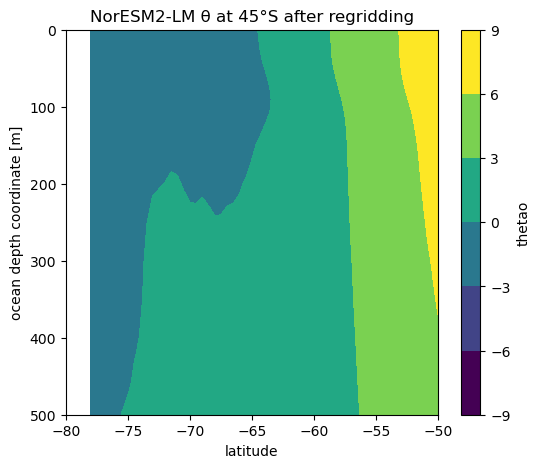

In [125]:
plt.figure(figsize=(6, 5))
da_interp.plot.contourf(x='latitude', y='lev', cmap='viridis')
plt.gca().invert_yaxis()
plt.title(f"{model_name} θ at 45°S after regridding")
plt.show()


In [145]:
# models

['CESM2-FV2',
 'IPSL-CM6A-LR',
 'CESM2-WACCM-FV2',
 'IPSL-CM6A-LR-INCA',
 'CESM2-WACCM',
 'CESM2',
 'NorESM2-LM',
 'UKESM1-0-LL',
 'NorESM2-MM',
 'ACCESS-CM2',
 'CMCC-ESM2',
 'CMCC-CM2-SR5',
 'CIESM',
 'CNRM-CM6-1',
 'CNRM-ESM2-1']

In [164]:
regridded_profiles = {}

for model in models[1:2]:
    print(f"\n▶ Regridding {model} ...")
    
    path = f"{base_dir}/{model}/thetao_45S_500m_profile_mean_{time_range.start}_{time_range.stop}.nc"
    try:
        da = xr.open_dataarray(path)
    except Exception as e:
        print(f"❌ 无法打开 {model}: {e}")
        continue

    # --- 检查坐标名称 ---
    lat_candidates = [n for n in da.coords if 'lat' in n.lower()]
    depth_candidates = [n for n in da.coords if any(k in n.lower() for k in ['lev', 'depth', 'z', 'olevel'])]
    if not lat_candidates or not depth_candidates:
        print(f"⚠️ {model}: 无法找到纬度或深度坐标, 跳过")
        continue

    lat_name = lat_candidates[0]
    depth_name = depth_candidates[0]

    # --- CESM 模型专属修复 ---
    if "CESM" in model.upper():
        print(f"⚙️ {model}: 检测到 CESM 模型，执行坐标修复...")

        # 修复纬度：如果 latitude 是索引 (整数)，用 lat 替换
        if "latitude" in da.dims and "lat" in da.coords:
            if np.issubdtype(da["latitude"].dtype, np.integer):
                print("   - 替换索引纬度 'latitude' 为真实纬度 'lat'")
                da = da.assign_coords(latitude=("latitude", da["lat"].data))
                da = da.swap_dims({"latitude": "lat"})

        # 修复深度单位为米
        depth_units = da[depth_name].attrs.get("units", "").lower()
        if "cm" in depth_units:
            print("   - 深度单位为厘米，已转换为米。")
            da = da.assign_coords({depth_name: da[depth_name] / 100})
            da[depth_name].attrs["units"] = "m"

    # --- 统一纬度为 latitude ---
    if lat_name != "latitude":
        da = da.rename({lat_name: "latitude"})

    # --- 插值 ---
    try:
        da_interp = da.interp(
            latitude=target_lat,
            **{depth_name: target_depth},
            kwargs={"fill_value": "extrapolate"}
        )
    except Exception as e:
        print(f"⚠️ {model}: interp 失败 ({e})")
        continue

    # --- 标准化深度坐标 ---
    if depth_name != "lev":
        da_interp = da_interp.rename({depth_name: "lev"})

    regridded_profiles[model] = da_interp
    print(f"✅ {model}: regrid 成功 → shape {da_interp.shape}")

print(f"\n✅ 共成功 regrid {len(regridded_profiles)} 个模型")



▶ Regridding IPSL-CM6A-LR ...
⚠️ IPSL-CM6A-LR: interp 失败 (Dimensions {'latitude'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'olevel': 41, 'y': 121}))

✅ 共成功 regrid 0 个模型


In [166]:
depth_name

'olevel'

In [165]:
da

<xarray.DataArray 'thetao' (olevel: 41, y: 121)> Size: 20kB
[4961 values with dtype=float32]
Coordinates:
  * olevel    (olevel) float32 164B 0.5058 1.556 2.668 ... 457.6 508.6 565.3
    latitude  (y) float32 484B ...
    nav_lon   (y) float32 484B ...
Dimensions without coordinates: y

In [150]:
da

<xarray.DataArray 'thetao' (lev: 35, latitude: 65)> Size: 9kB
[2275 values with dtype=float32]
Coordinates:
    nlat      (latitude) int32 260B 1 2 3 4 5 6 7 8 ... 58 59 60 61 62 63 64 65
    lat       (latitude) float64 520B ...
    lon       (latitude) float64 520B ...
    nlon      int32 4B ...
  * lev       (lev) float64 280B 5.0 15.0 25.0 35.0 ... 443.4 482.7 527.7 579.4
  * latitude  (latitude) int32 260B 1 2 3 4 5 6 7 8 ... 58 59 60 61 62 63 64 65

Before: ('lev', 'latitude')
✅ replaced 'latitude' with 'lat' coordinate
After: ('lev', 'lat')
Latitude range: -79.22052260746206 → -45.03003474927595
✅ Interpolation successful: (51, 61)


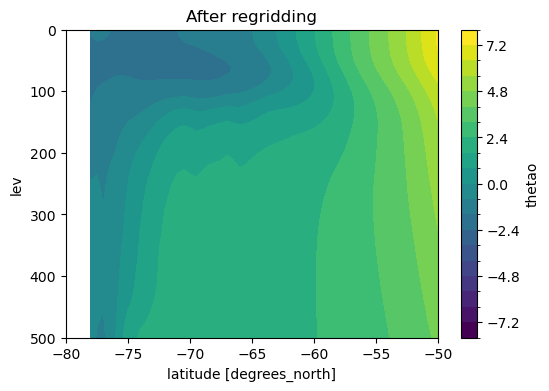

In [155]:
# 假设 da 是上图中的 DataArray
print("Before:", da.dims)

# 1️⃣ 确认纬度变量和索引纬度的关系
if 'latitude' in da.dims and 'lat' in da.coords:
    # 替换掉 latitude 索引，用真实纬度值
    da = da.assign_coords(latitude=('latitude', da['lat'].data))
    da = da.swap_dims({'latitude': 'lat'})
    print("✅ replaced 'latitude' with 'lat' coordinate")

print("After:", da.dims)
print("Latitude range:", da['lat'].min().item(), "→", da['lat'].max().item())

# 2️⃣ 执行插值
da_interp = da.interp(lat=target_lat, lev=target_depth, kwargs={"fill_value": "extrapolate"})
print("✅ Interpolation successful:", da_interp.shape)

# 3️⃣ 绘图验证
plt.figure(figsize=(6, 4))
da_interp.plot.contourf(x='lat', y='lev', cmap='viridis', levels=20)
plt.gca().invert_yaxis()
plt.title("After regridding")
plt.show()


In [144]:
regridded_profiles['CESM2-FV2']

<xarray.DataArray 'thetao' (lev: 51, latitude: 61)> Size: 25kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
    nlat      (latitude) float64 488B -80.0 -79.5 -79.0 ... -51.0 -50.5 -50.0
    lat       (latitude) float64 488B -122.5 -122.2 -122.0 ... -106.7 -106.5
    lon       (latitude) float64 488B 320.6 320.6 320.6 ... 320.6 320.6 320.6
    nlon      int32 4B 1
  * latitude  (latitude) float64 488B -80.0 -79.5 -79.0 ... -51.0 -50.5 -50.0
  * lev       (lev) float64 408B 0.0 10.0 20.0 30.0 ... 470.0 480.0 490.0 500.0

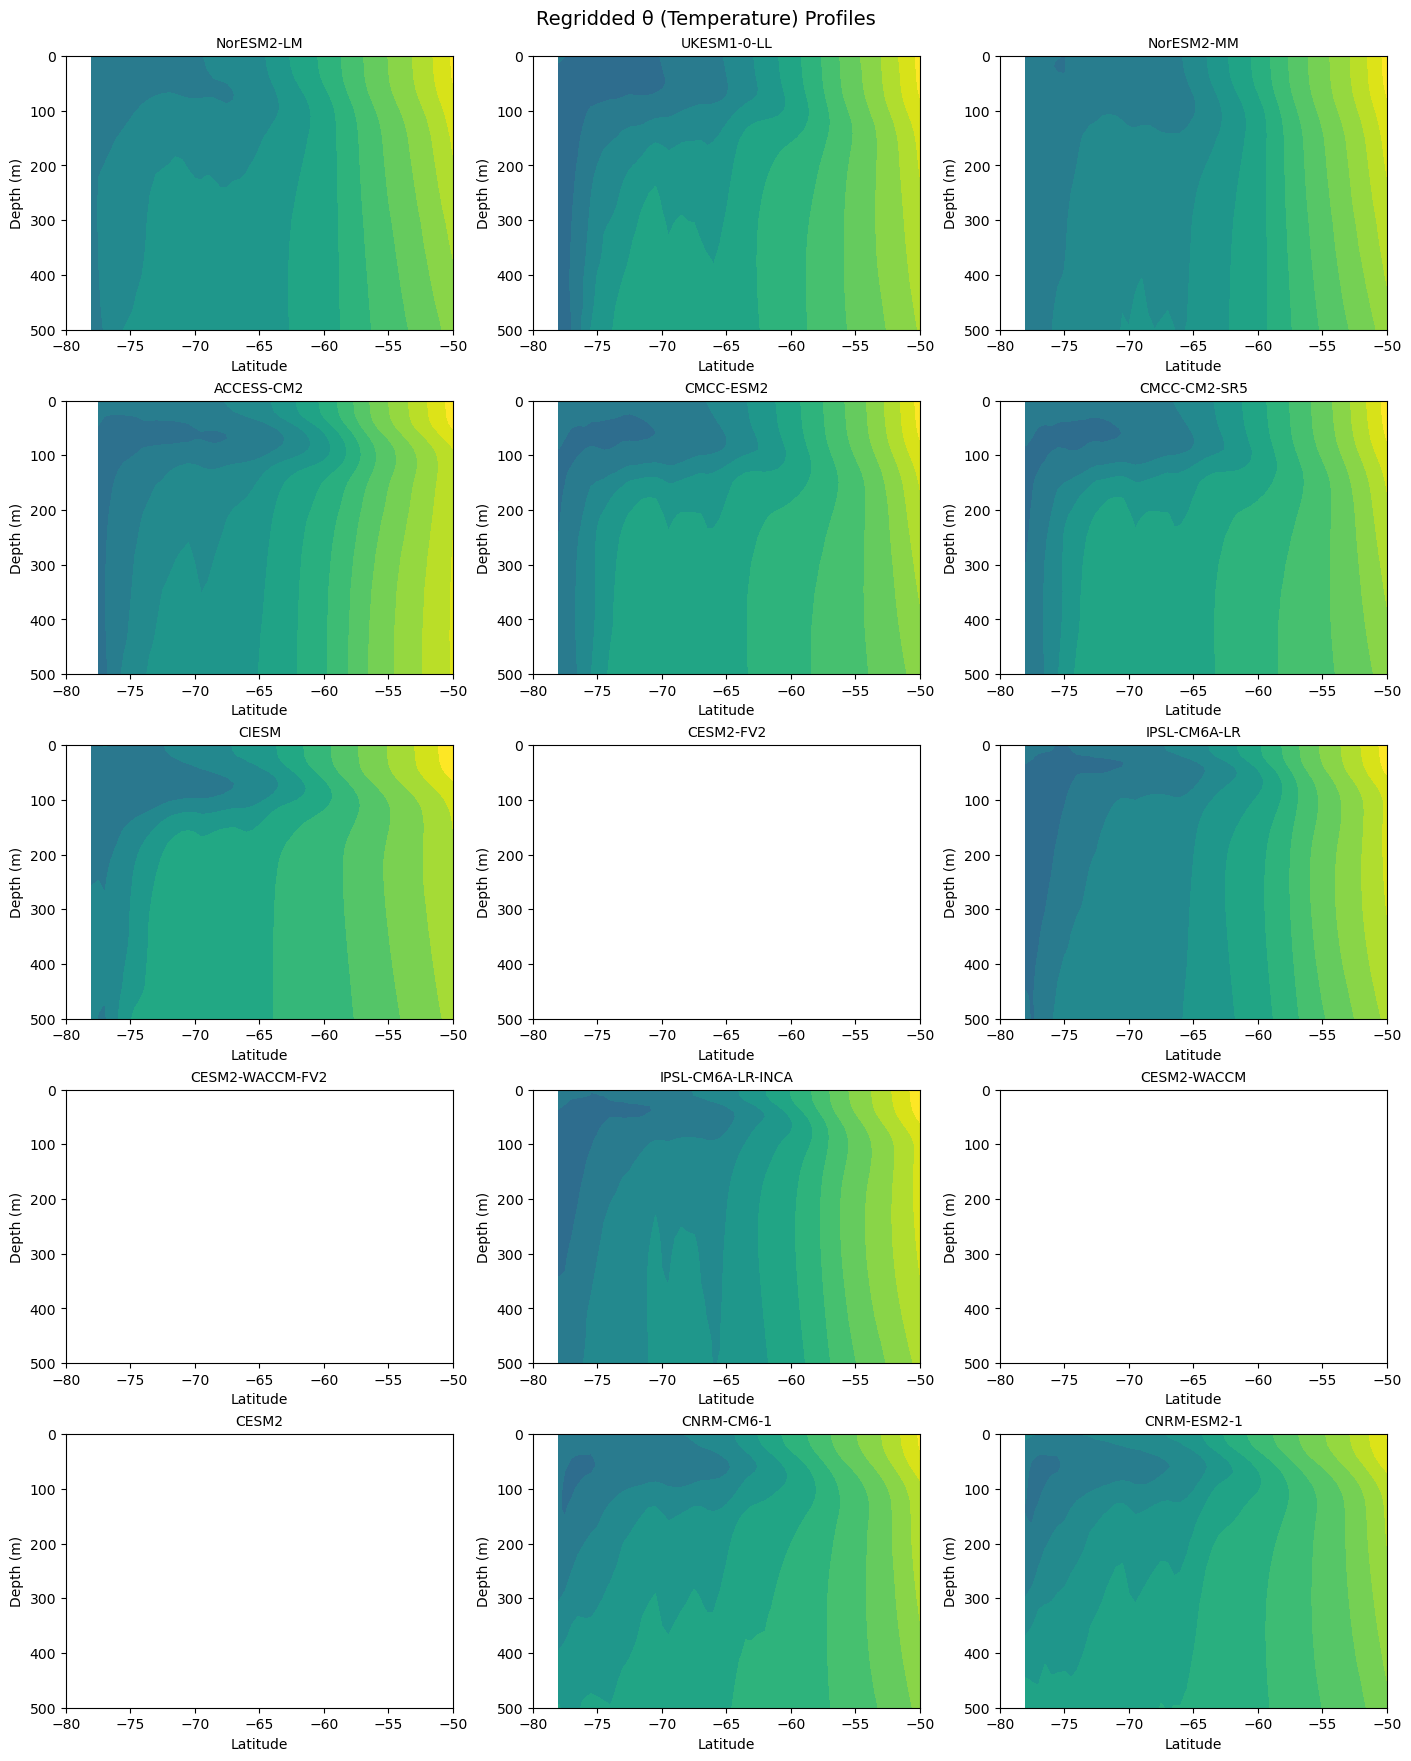

In [143]:
import matplotlib.pyplot as plt

# 确保有 regridded 模型
if not regridded_profiles:
    print("⚠️ 没有可用的 regridded 模型数据！")
else:
    n = len(regridded_profiles)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5), constrained_layout=True)

    for ax, (model, da) in zip(axes.flat, regridded_profiles.items()):
        try:
            # 绘制纬度-深度图
            da.plot.contourf(
                x='latitude', y='lev', cmap='viridis',
                levels=20, ax=ax, add_colorbar=False
            )
            ax.invert_yaxis()
            ax.set_title(model, fontsize=10)
            ax.set_xlabel('Latitude')
            ax.set_ylabel('Depth (m)')
        except Exception as e:
            ax.text(0.5, 0.5, f"Plot failed:\n{e}", ha='center', va='center', fontsize=8)
            ax.set_title(model, fontsize=10)
            ax.axis('off')

    # 移除多余子图
    for ax in axes.flat[n:]:
        ax.remove()

    plt.suptitle("Regridded θ (Temperature) Profiles", fontsize=14)
    plt.show()
